# 🍛 YOLOv12 Bangladesh Street Food Detection Training

<div align="center">

[![Roboflow](https://img.shields.io/badge/Roboflow-Dataset-blue?style=for-the-badge&logo=roboflow)](https://roboflow.com)
[![YOLOv12](https://img.shields.io/badge/YOLOv12-Model-success?style=for-the-badge&logo=python)](https://github.com/sunsmarterjie/yolov12)
[![arXiv](https://img.shields.io/badge/arXiv-2502.12524-b31b1b.svg?style=for-the-badge&logo=arxiv)](https://arxiv.org/abs/2502.12524)
[![Python](https://img.shields.io/badge/Python-3.8+-blue?style=for-the-badge&logo=python)](https://python.org)
[![PyTorch](https://img.shields.io/badge/PyTorch-2.0+-red?style=for-the-badge&logo=pytorch)](https://pytorch.org)

</div>

---

## 📖 Project Overview

This comprehensive notebook demonstrates how to train a state-of-the-art **YOLOv12** model for detecting popular Bangladesh street food items. We focus on three beloved street foods: **Singara**, **Peyaju**, and **Beguni**.

### 🎯 Key Features of YOLOv12
- **🔍 Attention-centric architecture** with area attention modules
- **🔗 Residual Efficient Layer Aggregation Networks (R-ELAN)**
- **⚡ Better accuracy-speed trade-off** compared to YOLOv11/YOLOv8
- **💫 FlashAttention optimization** for modern GPUs

### 🍴 Target Food Items
| Food Item | Description |
|-----------|-------------|
| **Singara** | Traditional triangular fried pastry |
| **Peyaju** | Onion fritters with spices |
| **Beguni** | Eggplant fritters in gram flour batter |

![YOLOv12 Architecture](hero.jpeg)

---

# 🔧 Environment Setup & System Configuration

<div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); padding: 15px; border-radius: 10px; color: white; margin: 10px 0;">
    <h3 style="margin: 0; color: white;">⚙️ Setting up the development environment for YOLOv12 training</h3>
    <p style="margin: 5px 0 0 0; opacity: 0.9;">Configuring GPU access, installing dependencies, and preparing the workspace</p>
</div>

> **💡 Prerequisites**: This section ensures your system is ready for YOLOv12 training with optimal performance.

## 🖥️ GPU Compatibility Check

<div style="background:rgb(193, 170, 231); border-left: 4px solid #28a745; padding: 12px; margin: 10px 0;">
    <strong>🎯 FlashAttention Requirements:</strong><br>
    YOLOv12 leverages FlashAttention for optimal performance, requiring:
    <ul>
        <li>NVIDIA GPUs with <strong>Ampere architecture</strong> or newer</li>
        <li>RTX 30xx/40xx series, A100, H100, etc.</li>
        <li>CUDA Compute Capability ≥ 8.0</li>
    </ul>
</div>

In [2]:
# import shutil

# shutil.rmtree("/content/Bangladeshi-street-food-Dataset-3", ignore_errors=True)
# shutil.rmtree("/content/Bangladeshi-street-food-Dataset-3_3classes", ignore_errors=True)

In [3]:
!nvidia-smi

Mon Jun 30 17:47:28 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import os
import torch

HOME = os.getcwd()
print(f"Working directory: {HOME}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_capability = torch.cuda.get_device_capability(0)
    ampere_compatible = gpu_capability[0] >= 8

    print(f"GPU: {gpu_name}")
    print(f"Compute Capability: {gpu_capability}")
    print(f"FlashAttention Compatible: {'✅' if ampere_compatible else '❌'}")

    if not ampere_compatible:
        print("⚠️ FlashAttention will be disabled for this GPU")
else:
    print("⚠️ No GPU detected. Training will be slow on CPU.")

Working directory: /content
CUDA available: True
GPU: Tesla T4
Compute Capability: (7, 5)
FlashAttention Compatible: ❌
⚠️ FlashAttention will be disabled for this GPU


## 📦 YOLOv12 Installation & Dependencies

<div style="background:
rgb(189, 79, 103); border: 1px solidrgb(31, 136, 127); border-radius: 8px; padding: 12px; margin: 10px 0;">
    <strong>📋 Installation Overview:</strong>
    <ul>
        <li><strong>YOLOv12:</strong> Latest version from official GitHub repository</li>
        <li><strong>Roboflow:</strong> Dataset management and download</li>
        <li><strong>Supervision:</strong> Computer vision utilities</li>
        <li><strong>FlashAttention:</strong> GPU acceleration (optional)</li>
    </ul>
</div>

In [5]:
# Note: YOLOv12 installation command corrected based on official repository
!pip install -q git+https://github.com/sunsmarterjie/yolov12.git
!pip install -q roboflow supervision wandb python-dotenv

# Install FlashAttention (may fail on incompatible GPUs)
# FlashAttention is not required for YOLOv12 basic functionality
try:
    !pip install -q flash-attn>=2.0.0 --no-build-isolation
    print("✅ FlashAttention installed successfully")
except Exception as e:
    print(f"⚠️ FlashAttention installation failed: {e}")
    print("⚠️ Continuing without FlashAttention optimization")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ FlashAttention installed successfully


## 📚 Import Required Libraries

<div style="background:rgb(82, 56, 14); border: 1px solidrgb(66, 50, 26); border-radius: 8px; padding: 12px; margin: 10px 0;">
    <strong>🔧 Core Libraries:</strong>
    <code>PyTorch</code> • <code>OpenCV</code> • <code>Ultralytics</code> • <code>Supervision</code> • <code>Roboflow</code> • <code>Matplotlib</code>
</div>

In [6]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import yaml
import shutil
import random
import time
from pathlib import Path
from collections import defaultdict

from ultralytics import YOLO
import supervision as sv
from roboflow import Roboflow

print("✅ All libraries imported successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"OpenCV version: {cv2.__version__}")

FlashAttention is not available on this device. Using scaled_dot_product_attention instead.
✅ All libraries imported successfully
PyTorch version: 2.6.0+cu124
OpenCV version: 4.10.0


# 🗂️ Dataset Configuration & Management

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 20px; border-radius: 12px; color: white; margin: 15px 0;">
    <h2 style="margin: 0; color: white;">🍛 Bangladesh Street Food Dataset</h2>
    <p style="margin: 10px 0 0 0; opacity: 0.9;">Curated collection of 13 popular Bangladesh street foods with focus on 3 key items</p>
</div>

### 📊 Dataset Overview

We'll work with a professionally curated dataset featuring **13 popular Bangladesh street foods** and focus our training on **3 specific items** for optimal model performance:

| 🎯 **Selected Classes** | 📝 **Description** |
|-------------------------|-------------------|
| **Singara** | Traditional triangular fried pastry with savory filling |
| **Peyaju** | Crispy onion fritters seasoned with aromatic spices |
| **Beguni** | Golden eggplant fritters coated in spiced gram flour |

### 🏷️ Complete Dataset Classes
`beguni` • `chanachur` • `chotpoti` • `dim cake` • `fuska` • `jhalmuri` • `kulfi` • `murobba` • `papar` • `peyaju` • `puri` • `singara` • `tiler khaja`

---

In [7]:
# Bangladesh Street Food Classes
ALL_BANGLADESH_FOODS = [
    'beguni', 'chanachur', 'chotpoti', 'dim cake', 'fuska',
    'jhalmuri', 'kulfi', 'murobba', 'papar', 'peyaju',
    'puri', 'singara', 'tiler khaja'
]

# Selected 3 classes for focused training
SELECTED_CLASSES = [
    'singara',
    'peyaju',
    'beguni'
]

print(f"🍛 Bangladesh Street Food Detection")
print(f"Total available classes: {len(ALL_BANGLADESH_FOODS)}")
print(f"Selected for training: {SELECTED_CLASSES}")
print(f"Number of classes: {len(SELECTED_CLASSES)}")

# Dataset configuration (from actual data.yaml)
ROBOFLOW_WORKSPACE = "bengali-street-food-dataset"  # From data.yaml
ROBOFLOW_PROJECT = "bangladeshi-street-food-dataset"  # From data.yaml
DATASET_VERSION = 3  # From data.yaml

🍛 Bangladesh Street Food Detection
Total available classes: 13
Selected for training: ['singara', 'peyaju', 'beguni']
Number of classes: 3


<h4>🚀 Multiple Download Options Available</h4>

<ul>
  <li><strong>1️⃣ Direct Universe Download</strong> - No API key required</li>
  <li><strong>2️⃣ API Download</strong> - Requires Roboflow API key</li>
  <li><strong>3️⃣ Local Dataset</strong> - Use existing local files</li>
</ul>

In [ ]:
import os
from getpass import getpass

# Try to get API key from environment, otherwise prompt for it (optional)
ROBOFLOW_API_KEY = os.getenv('ROBOFLOW_API_KEY')

if not ROBOFLOW_API_KEY:
    print("Roboflow API key not found in environment variables.")
    print("You can either:")
    print("1. Enter your API key for authenticated downloads")
    print("2. Skip this and use the direct Universe download method")

    user_choice = input("Enter API key? (y/n): ").strip().lower()
    if user_choice == 'y':
        ROBOFLOW_API_KEY = getpass("Enter your Roboflow API key: ")
        os.environ["ROBOFLOW_API_KEY"] = ROBOFLOW_API_KEY
        print(f"✅ API key configured: {ROBOFLOW_API_KEY[:8]}...")
    else:
        print("⏭️ Skipping API key configuration - will use direct download")
else:
    os.environ["ROBOFLOW_API_KEY"] = ROBOFLOW_API_KEY
    print(f"✅ API key configured: {ROBOFLOW_API_KEY[:8]}...")

Roboflow API key not found in environment variables.
You can either:
1. Enter your API key for authenticated downloads
2. Skip this and use the direct Universe download method
Enter API key? (y/n): y
Enter your Roboflow API key: ··········
✅ API key configured: hJyCBPX2...


In [9]:
# Option 1: Use local dataset (set path below)
LOCAL_DATASET_PATH = "/media/nafiz/NewVolume/ML-From-Scratch/Projects/YOLO11 Bangladesh Street Food Detection/Bangladeshi street food Dataset.v2-bangladeshi-street-food-dataset-v1.yolov12"

# Option 2: Download from Roboflow (uses API key above)
USE_LOCAL_DATASET = LOCAL_DATASET_PATH is not None

if USE_LOCAL_DATASET:
    print(f"✅ Using local dataset: {LOCAL_DATASET_PATH}")
    # Verify local dataset exists
    if os.path.exists(LOCAL_DATASET_PATH):
        required_folders = ['train', 'valid', 'test']
        missing_folders = [f for f in required_folders if not os.path.exists(f"{LOCAL_DATASET_PATH}/{f}")]
        if missing_folders:
            print(f"⚠️ Warning: Missing folders in local dataset: {missing_folders}")
        else:
            print("✅ Local dataset structure verified")
    else:
        print(f"❌ Local dataset path does not exist: {LOCAL_DATASET_PATH}")
        USE_LOCAL_DATASET = False
else:
    print("📡 Will download dataset from Roboflow")

✅ Using local dataset: /media/nafiz/NewVolume/ML-From-Scratch/Projects/YOLO11 Bangladesh Street Food Detection/Bangladeshi street food Dataset.v2-bangladeshi-street-food-dataset-v1.yolov12
❌ Local dataset path does not exist: /media/nafiz/NewVolume/ML-From-Scratch/Projects/YOLO11 Bangladesh Street Food Detection/Bangladeshi street food Dataset.v2-bangladeshi-street-food-dataset-v1.yolov12


In [10]:
def download_bangladesh_dataset():
    """Download Bangladesh Street Food dataset from Roboflow"""
    try:
        rf = Roboflow(api_key=ROBOFLOW_API_KEY)
        project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)

        # Download in YOLOv8 format (compatible with YOLOv12)
        dataset = project.version(DATASET_VERSION).download("yolov8")

        print(f"✅ Dataset downloaded successfully")
        print(f"Location: {dataset.location}")
        return dataset.location

    except Exception as e:
        print(f"❌ Failed to download dataset: {e}")
        print("Please check your API key and project details")
        return None

def download_bangladesh_dataset_universe():
    """Download Bangladesh Street Food dataset directly from Roboflow Universe"""
    try:
        print("🌐 Downloading from Roboflow Universe...")

        # Direct download URL from Roboflow Universe
        universe_url = "https://universe.roboflow.com/bengali-street-food-dataset/bangladeshi-street-food-dataset/dataset/3"

        # Use roboflow library to download from universe
        import requests

        # Download using roboflow universe direct method
        rf = Roboflow()
        project = rf.workspace("bengali-street-food-dataset").project("bangladeshi-street-food-dataset")
        dataset = project.version(3).download("yolov8")

        print(f"✅ Dataset downloaded successfully from Universe")
        print(f"Location: {dataset.location}")
        return dataset.location

    except Exception as e:
        print(f"❌ Universe download failed: {e}")
        print("Trying alternative download method...")

        # Alternative method using wget/curl
        try:
            import subprocess
            download_dir = "bangladeshi_street_food_dataset"

            # Create download directory
            if os.path.exists(download_dir):
                shutil.rmtree(download_dir)
            os.makedirs(download_dir)

            print("🔄 Attempting alternative download method...")
            print("Note: This may require manual download from the Universe link")
            print(f"Universe Link: {universe_url}")

            return None

        except Exception as e2:
            print(f"❌ Alternative download also failed: {e2}")
            return None

# Legacy download functions (kept for compatibility)
def download_bangladesh_dataset_api():
    """Download Bangladesh Street Food dataset using Roboflow API"""
    if not ROBOFLOW_API_KEY:
        print("❌ No API key available for authenticated download")
        return None

    try:
        rf = Roboflow(api_key=ROBOFLOW_API_KEY)
        project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)

        # Download in YOLOv8 format (compatible with YOLOv12)
        dataset = project.version(DATASET_VERSION).download("yolov8")

        print(f"✅ Dataset downloaded successfully via API")
        print(f"Location: {dataset.location}")
        return dataset.location

    except Exception as e:
        print(f"❌ API download failed: {e}")
        print("Please check your API key and project details")
        return None

# Priority order: Local -> Universe -> API
dataset_path = None

if USE_LOCAL_DATASET and os.path.exists(LOCAL_DATASET_PATH):
    dataset_path = LOCAL_DATASET_PATH
    print(f"✅ Using local dataset: {dataset_path}")
    !ls {dataset_path}
else:
    print("🔄 Local dataset not found, attempting download...")

    # Try Universe download first (no API key needed)
    print("\n1️⃣ Trying Universe download...")
    dataset_path = download_bangladesh_dataset_universe()

    # If Universe fails, try API download
    if not dataset_path and ROBOFLOW_API_KEY:
        print("\n2️⃣ Universe download failed, trying API download...")
        dataset_path = download_bangladesh_dataset_api()

    # Final check
    if dataset_path:
        !ls {dataset_path}
        print(f"\n✅ Dataset ready at: {dataset_path}")
    else:
        print("\n❌ All download methods failed!")
        print("📋 Manual Download Instructions:")
        print(f"1. Visit: https://universe.roboflow.com/bengali-street-food-dataset/bangladeshi-street-food-dataset")
        print("2. Click 'Download Dataset'")
        print("3. Select 'YOLOv8 PyTorch' format")
        print("4. Extract to your desired location")
        print("5. Update LOCAL_DATASET_PATH variable above")

        # Provide fallback option
        manual_path = input("\nIf you've downloaded manually, enter the path (or press Enter to skip): ").strip()
        if manual_path and os.path.exists(manual_path):
            dataset_path = manual_path
            print(f"✅ Using manually specified dataset: {dataset_path}")
        else:
            print("⏭️ Continuing without dataset - some cells will be skipped")

print("📚 Dataset download functions loaded")
print("🎯 Multiple download methods available:")
print("   1. Direct Universe Download (no API key needed)")
print("   2. Manual Download (from web interface)")
print("   3. API Download (requires API key)")
print("   4. Local Dataset (if already available)")
print("\n⬇️ Execute the cells below to download the dataset")

🔄 Local dataset not found, attempting download...

1️⃣ Trying Universe download...
🌐 Downloading from Roboflow Universe...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Bangladeshi-street-food-Dataset-3 in yolov8:: 100%|██████████| 15860/15860 [00:02<00:00, 6004.03it/s]


✅ Dataset downloaded successfully from Universe
Location: /content/Bangladeshi-street-food-Dataset-3
data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid

✅ Dataset ready at: /content/Bangladeshi-street-food-Dataset-3
📚 Dataset download functions loaded
🎯 Multiple download methods available:
   1. Direct Universe Download (no API key needed)
   2. Manual Download (from web interface)
   3. API Download (requires API key)
   4. Local Dataset (if already available)

⬇️ Execute the cells below to download the dataset


## ⚙️ Dataset Preparation for YOLOv12

<div style="background: #fff3e0; border-left: 5px solid #ff9800; padding: 15px; margin: 12px 0;">
    <strong>🔧 Preparation Steps:</strong>
    <ul style="margin: 8px 0;">
        <li>Update <code>data.yaml</code> configuration file</li>
        <li>Set absolute paths for YOLOv12 compatibility</li>
        <li>Verify dataset structure and integrity</li>
        <li>Generate dataset statistics</li>
    </ul>
</div>

In [11]:
if dataset_path:
    # Fix data.yaml paths for YOLOv12 compatibility
    data_yaml_path = f"{dataset_path}/data.yaml"

    # Read current data.yaml
    with open(data_yaml_path, 'r') as f:
        data_config = yaml.safe_load(f)

    print("Original data.yaml:")
    print(yaml.dump(data_config, default_flow_style=False))

    # Update paths to be absolute for YOLOv12 compatibility
    data_config.update({
        'path': dataset_path,
        'train': 'train/images',
        'val': 'valid/images',
        'test': 'test/images'
    })

    # Write updated data.yaml
    with open(data_yaml_path, 'w') as f:
        yaml.dump(data_config, f, default_flow_style=False)

    print("\nUpdated data.yaml:")
    !cat {data_yaml_path}

    # Display dataset statistics
    print(f"\n📊 DATASET INFORMATION:")
    print(f"Dataset path: {dataset_path}")
    print(f"Number of classes: {data_config['nc']}")
    print(f"Classes: {data_config['names']}")

    # Count images in each split
    for split in ['train', 'valid', 'test']:
        split_path = f"{dataset_path}/{split}/images"
        if os.path.exists(split_path):
            image_count = len([f for f in os.listdir(split_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
            print(f"{split.capitalize()} images: {image_count}")
else:
    print("No dataset available to process")

Original data.yaml:
names:
- beguni
- chanachur
- chotpoti
- dim cake
- fuska
- jhalmuri
- kulfi
- murobba
- papar
- peyaju
- puri
- singara
- tiler khaja
nc: 13
roboflow:
  license: CC BY 4.0
  project: bangladeshi-street-food-dataset
  url: https://universe.roboflow.com/bengali-street-food-dataset/bangladeshi-street-food-dataset/dataset/3
  version: 3
  workspace: bengali-street-food-dataset
test: ../test/images
train: ../train/images
val: ../valid/images


Updated data.yaml:
names:
- beguni
- chanachur
- chotpoti
- dim cake
- fuska
- jhalmuri
- kulfi
- murobba
- papar
- peyaju
- puri
- singara
- tiler khaja
nc: 13
path: /content/Bangladeshi-street-food-Dataset-3
roboflow:
  license: CC BY 4.0
  project: bangladeshi-street-food-dataset
  url: https://universe.roboflow.com/bengali-street-food-dataset/bangladeshi-street-food-dataset/dataset/3
  version: 3
  workspace: bengali-street-food-dataset
test: test/images
train: train/images
val: valid/images

📊 DATASET INFORMATION:
Dataset pat

# 🔍 Dataset Exploration & Visualization

<div style="background: linear-gradient(45deg, #ff6b6b, #ffa726); padding: 18px; border-radius: 12px; color: white; margin: 15px 0;">
    <h3 style="margin: 0; color: white;">📸 Visual Dataset Analysis</h3>
    <p style="margin: 8px 0 0 0; opacity: 0.95;">Exploring sample images with bounding box annotations and class distributions</p>
</div>

## 🖼️ Sample Image Visualization

Let's examine some sample images from our Bangladesh street food dataset to understand:
- **Image quality** and variety
- **Annotation accuracy** and bounding box placement  
- **Class distribution** across the dataset
- **Visual characteristics** of each food type

---

🖼️ Sample Images from Bangladesh Street Food Dataset


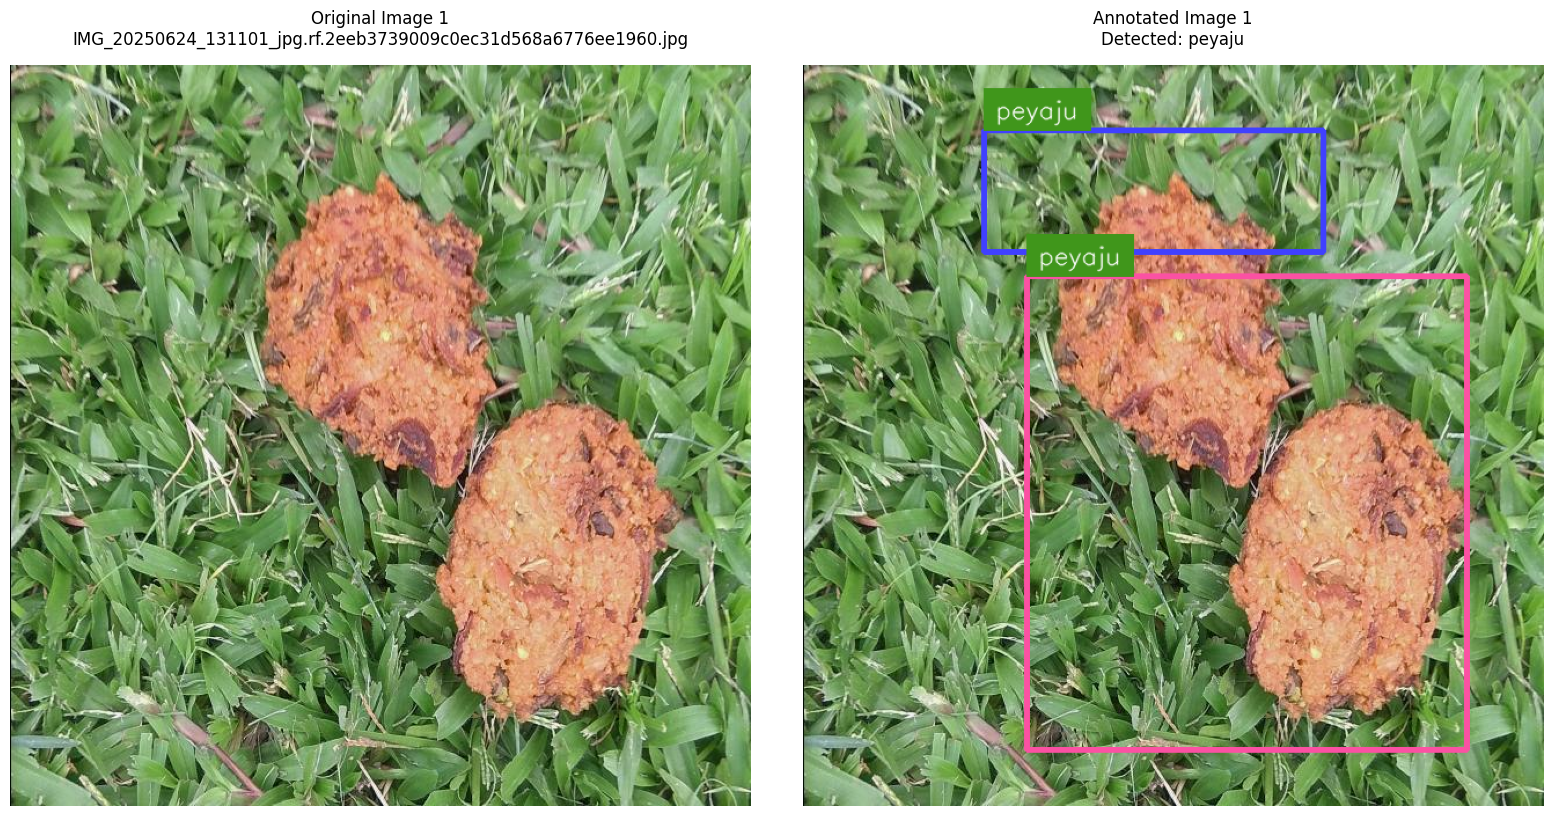

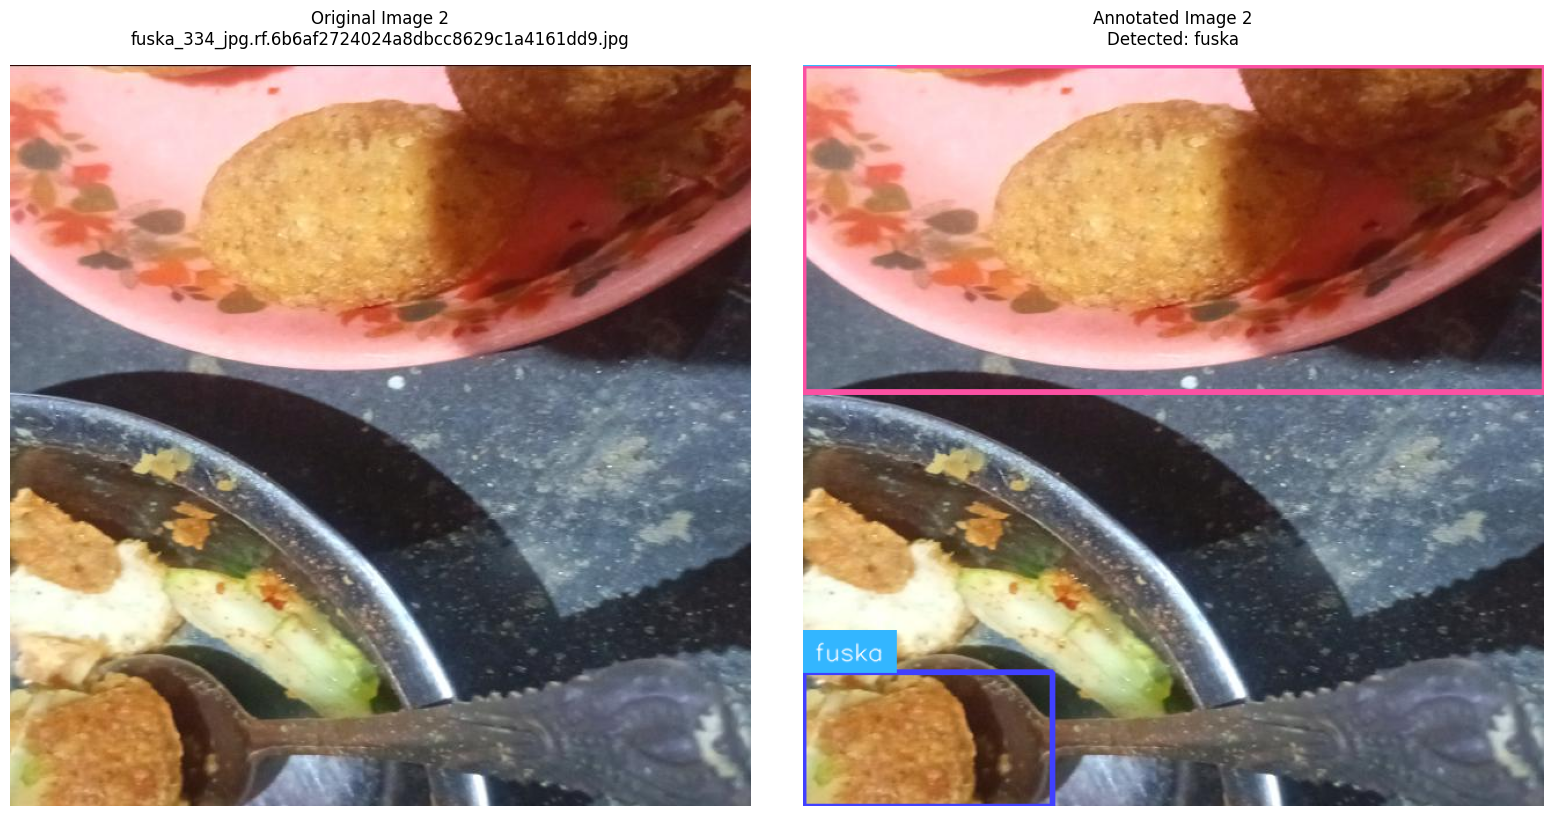

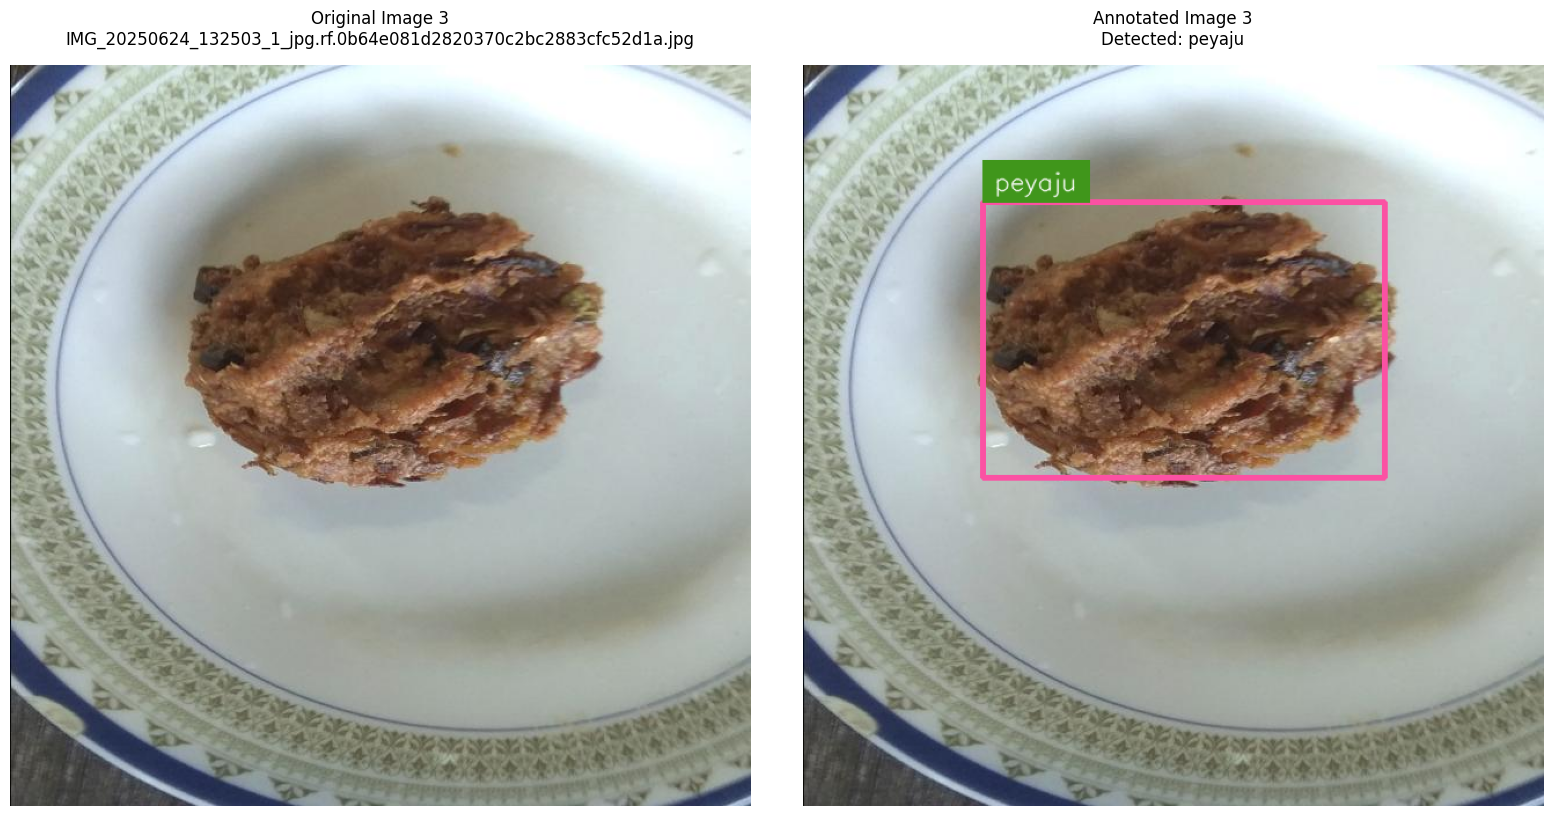

✅ Visualized 3 sample images with supervision annotators

📊 Dataset Statistics:
   • Total training images: 5904
   • Number of classes: 13
   • Classes: beguni, chanachur, chotpoti, dim cake, fuska, jhalmuri, kulfi, murobba, papar, peyaju, puri, singara, tiler khaja


In [12]:
import os
import yaml
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import supervision as sv

if dataset_path and os.path.exists(dataset_path):
    print("🖼️ Sample Images from Bangladesh Street Food Dataset")

    # Load data.yaml to get class names
    with open(f"{dataset_path}/data.yaml", 'r') as f:
        data_info = yaml.safe_load(f)
    class_names = data_info['names']

    # Initialize supervision annotators
    box_annotator = sv.BoxAnnotator(
        thickness=3,
        color_lookup=sv.ColorLookup.INDEX  # Different color for each class
    )
    label_annotator = sv.LabelAnnotator(
        text_scale=0.7,
        text_color=sv.Color.WHITE
    )

    # Get sample images from train set
    train_images_path = f"{dataset_path}/train/images"
    train_labels_path = f"{dataset_path}/train/labels"

    if os.path.exists(train_images_path):
        image_files = [f for f in os.listdir(train_images_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

        # Select 3 random images for side-by-side visualization
        sample_images = random.sample(image_files, min(3, len(image_files)))

        for idx, img_file in enumerate(sample_images):
            img_path = f"{train_images_path}/{img_file}"
            label_path = f"{train_labels_path}/{os.path.splitext(img_file)[0]}.txt"

            # Load image
            image = cv2.imread(img_path)
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            height, width = image_rgb.shape[:2]

            # Create annotated image copy
            annotated_image = image_rgb.copy()

            # Load labels and create detections
            labels = []
            if os.path.exists(label_path):
                xyxy_boxes = []
                class_ids = []

                with open(label_path, 'r') as f:
                    for line in f.readlines():
                        parts = line.strip().split()
                        if len(parts) >= 5:
                            class_id = int(parts[0])
                            class_name = class_names[class_id] if class_id < len(class_names) else f"Class_{class_id}"

                            # Convert YOLO format to xyxy pixel coordinates
                            x_center, y_center, bbox_width, bbox_height = map(float, parts[1:5])
                            x1 = int((x_center - bbox_width/2) * width)
                            y1 = int((y_center - bbox_height/2) * height)
                            x2 = int((x_center + bbox_width/2) * width)
                            y2 = int((y_center + bbox_height/2) * height)

                            xyxy_boxes.append([x1, y1, x2, y2])
                            class_ids.append(class_id)
                            labels.append(f"{class_name}")

                # Create detections object if there are any boxes
                if xyxy_boxes:
                    detections = sv.Detections(
                        xyxy=np.array(xyxy_boxes),
                        class_id=np.array(class_ids)
                    )

                    # Apply annotations using supervision
                    annotated_image = box_annotator.annotate(
                        scene=annotated_image,
                        detections=detections
                    )
                    annotated_image = label_annotator.annotate(
                        scene=annotated_image,
                        detections=detections,
                        labels=labels
                    )

            # Create side-by-side visualization
            plt.figure(figsize=(16, 8))

            # Original image
            plt.subplot(1, 2, 1)
            plt.imshow(image_rgb)
            plt.title(f"Original Image {idx+1}\n{os.path.basename(img_file)}", fontsize=12, pad=15)
            plt.axis('off')

            # Annotated image
            plt.subplot(1, 2, 2)
            plt.imshow(annotated_image)
            annotation_title = f"Annotated Image {idx+1}"
            if labels:
                unique_labels = list(set([label.split()[0] for label in labels]))  # Remove confidence scores
                annotation_title += f"\nDetected: {', '.join(unique_labels)}"
            plt.title(annotation_title, fontsize=12, pad=15)
            plt.axis('off')

            plt.tight_layout()
            plt.show()

        print(f"✅ Visualized {len(sample_images)} sample images with supervision annotators")

        # Print dataset statistics
        total_images = len(image_files)
        total_classes = len(class_names)
        print(f"\n📊 Dataset Statistics:")
        print(f"   • Total training images: {total_images}")
        print(f"   • Number of classes: {total_classes}")
        print(f"   • Classes: {', '.join(class_names)}")

    else:
        print("❌ Training images directory not found")
else:
    print("❌ No dataset available for visualization")

## 🎯 Dataset Filtering & Class Selection

<div style="background: #e8f5e8; border: 2px solid #4caf50; border-radius: 10px; padding: 15px; margin: 12px 0;">
    <h4 style="margin: 0 0 8px 0; color: #2e7d32;">🔽 Filtering Strategy</h4>
    <p style="margin: 0; color: #388e3c;">
        <strong>Objective:</strong> Create a focused dataset with only our 3 selected Bangladesh street food classes
        for optimal training performance and model accuracy.
    </p>
</div>

### 📋 Selected Classes for Training:
- 🔺 **Singara** - Traditional triangular pastries
- 🧅 **Peyaju** - Spiced onion fritters  
- 🍆 **Beguni** - Eggplant fritters

---

In [13]:
import os
import shutil
import yaml
from collections import defaultdict
import random
from sklearn.model_selection import train_test_split

def filter_and_balance_dataset_for_3_classes(dataset_path, selected_classes, train_ratio=0.7, valid_ratio=0.2, test_ratio=0.1, random_seed=42):

    if not dataset_path or not os.path.exists(dataset_path):
        return None, None

    # Set random seed for reproducibility
    random.seed(random_seed)

    print(f"🔍 Filtering and balancing dataset for: {selected_classes}")
    print(f"📊 Target split ratios - Train: {train_ratio:.1%}, Valid: {valid_ratio:.1%}, Test: {test_ratio:.1%}")

    # Create filtered dataset directory
    base_name = os.path.basename(dataset_path.rstrip('/'))
    filtered_path = os.path.join(os.path.dirname(dataset_path), f"{base_name}_3classes_balanced")

    if os.path.exists(filtered_path):
        shutil.rmtree(filtered_path)
    os.makedirs(filtered_path)

    # Read original data.yaml
    with open(f"{dataset_path}/data.yaml", 'r') as f:
        original_data = yaml.safe_load(f)

    original_classes = original_data['names']
    print(f"Original classes ({len(original_classes)}): {original_classes}")

    # Create class mapping
    original_class_to_idx = {name: idx for idx, name in enumerate(original_classes)}
    selected_indices = [original_class_to_idx[cls] for cls in selected_classes if cls in original_class_to_idx]
    new_class_mapping = {old_idx: new_idx for new_idx, old_idx in enumerate(selected_indices)}

    print(f"Selected indices: {selected_indices}")
    print(f"Class mapping: {new_class_mapping}")

    # Step 1: Collect all images with selected classes from all splits
    all_valid_images = []

    for split in ['train', 'valid', 'test']:
        split_src = f"{dataset_path}/{split}"
        if not os.path.exists(split_src):
            continue

        images_src = f"{split_src}/images"
        labels_src = f"{split_src}/labels"

        if not os.path.exists(images_src) or not os.path.exists(labels_src):
            continue

        image_files = [f for f in os.listdir(images_src) if f.endswith(('.jpg', '.jpeg', '.png'))]

        for image_file in image_files:
            label_file = os.path.splitext(image_file)[0] + '.txt'
            image_path = f"{images_src}/{image_file}"
            label_path = f"{labels_src}/{label_file}"

            if not os.path.exists(label_path):
                continue

            # Read and filter labels
            with open(label_path, 'r') as f:
                lines = f.readlines()

            new_labels = []
            has_selected_class = False
            class_counts_in_image = defaultdict(int)

            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id = int(parts[0])
                    if class_id in new_class_mapping:
                        new_class_id = new_class_mapping[class_id]
                        new_line = f"{new_class_id} {' '.join(parts[1:])}\n"
                        new_labels.append(new_line)
                        has_selected_class = True
                        class_counts_in_image[new_class_id] += 1

            # Keep images with selected classes
            if has_selected_class:
                all_valid_images.append({
                    'image_file': image_file,
                    'image_path': image_path,
                    'label_file': label_file,
                    'new_labels': new_labels,
                    'class_counts': dict(class_counts_in_image),
                    'primary_class': max(class_counts_in_image, key=class_counts_in_image.get)  # Class with most objects
                })

    print(f"📁 Total valid images found: {len(all_valid_images)}")

    # Step 2: Group images by primary class for stratified splitting
    images_by_class = defaultdict(list)
    for img_info in all_valid_images:
        images_by_class[img_info['primary_class']].append(img_info)

    print(f"📊 Images per class:")
    for class_idx, images in images_by_class.items():
        class_name = selected_classes[class_idx]
        print(f"  {class_name}: {len(images)} images")

    # Step 3: Create stratified splits for each class
    train_images, valid_images, test_images = [], [], []

    for class_idx, images in images_by_class.items():
        class_name = selected_classes[class_idx]
        n_images = len(images)

        if n_images < 3:
            print(f"⚠️ Warning: {class_name} has only {n_images} images. Adding all to train.")
            train_images.extend(images)
            continue

        # Calculate split sizes
        n_test = max(1, int(n_images * test_ratio))
        n_valid = max(1, int(n_images * valid_ratio))
        n_train = n_images - n_test - n_valid

        # Shuffle images for this class
        random.shuffle(images)

        # Split images
        class_train = images[:n_train]
        class_valid = images[n_train:n_train + n_valid]
        class_test = images[n_train + n_valid:n_train + n_valid + n_test]

        train_images.extend(class_train)
        valid_images.extend(class_valid)
        test_images.extend(class_test)

        print(f"  {class_name} split: {len(class_train)} train, {len(class_valid)} valid, {len(class_test)} test")

    # Shuffle final splits
    random.shuffle(train_images)
    random.shuffle(valid_images)
    random.shuffle(test_images)

    print(f"\n📊 FINAL SPLIT SIZES:")
    print(f"  Train: {len(train_images)} images")
    print(f"  Valid: {len(valid_images)} images")
    print(f"  Test: {len(test_images)} images")

    # Step 4: Create directory structure and copy files
    splits_data = {
        'train': train_images,
        'valid': valid_images,
        'test': test_images
    }

    stats = defaultdict(lambda: defaultdict(int))

    for split_name, images_list in splits_data.items():
        split_dst = f"{filtered_path}/{split_name}"
        os.makedirs(f"{split_dst}/images", exist_ok=True)
        os.makedirs(f"{split_dst}/labels", exist_ok=True)

        for img_info in images_list:
            # Copy image
            dst_image_path = f"{split_dst}/images/{img_info['image_file']}"
            shutil.copy2(img_info['image_path'], dst_image_path)

            # Save filtered labels
            dst_label_path = f"{split_dst}/labels/{img_info['label_file']}"
            with open(dst_label_path, 'w') as f:
                f.writelines(img_info['new_labels'])

            # Update statistics
            for class_id, count in img_info['class_counts'].items():
                stats[split_name][selected_classes[class_id]] += count

    # Step 5: Create new data.yaml
    new_data_yaml = {
        'path': filtered_path,
        'train': 'train/images',
        'val': 'valid/images',
        'test': 'test/images',
        'nc': len(selected_classes),
        'names': selected_classes
    }

    with open(f"{filtered_path}/data.yaml", 'w') as f:
        yaml.dump(new_data_yaml, f, default_flow_style=False)

    # Step 6: Print detailed statistics
    print(f"\n📊 BALANCED DATASET STATISTICS")
    print("=" * 50)

    grand_total = 0
    for split in ['train', 'valid', 'test']:
        if split in stats:
            print(f"\n{split.upper()}:")
            split_total = sum(stats[split].values())
            grand_total += split_total

            for class_name in selected_classes:
                count = stats[split].get(class_name, 0)
                pct = (count/split_total*100) if split_total > 0 else 0
                print(f"  {class_name}: {count} objects ({pct:.1f}%)")
            print(f"  Total: {split_total} objects")

    print(f"\n🎯 OVERALL DISTRIBUTION:")
    for class_name in selected_classes:
        total_class_objects = sum(stats[split].get(class_name, 0) for split in stats)
        pct = (total_class_objects/grand_total*100) if grand_total > 0 else 0
        print(f"  {class_name}: {total_class_objects} objects ({pct:.1f}%)")
    print(f"  Grand Total: {grand_total} objects")

    # Step 7: Verify balance quality
    print(f"\n✅ BALANCE QUALITY CHECK:")
    for class_name in selected_classes:
        train_count = stats['train'].get(class_name, 0)
        valid_count = stats['valid'].get(class_name, 0)
        test_count = stats['test'].get(class_name, 0)
        total_class = train_count + valid_count + test_count

        if total_class > 0:
            train_pct = train_count / total_class * 100
            valid_pct = valid_count / total_class * 100
            test_pct = test_count / total_class * 100
            print(f"  {class_name}: Train {train_pct:.1f}%, Valid {valid_pct:.1f}%, Test {test_pct:.1f}%")

    return filtered_path, stats

# Filter dataset if it has more than 3 classes
if dataset_path:
    with open(f"{dataset_path}/data.yaml", 'r') as f:
        data_info = yaml.safe_load(f)

    if len(data_info['names']) > 3:
        print(f"Filtering from {len(data_info['names'])} classes to 3...")
        filtered_dataset_path, filter_stats = filter_and_balance_dataset_for_3_classes(dataset_path, SELECTED_CLASSES)
        if filtered_dataset_path:
            dataset_path = filtered_dataset_path
            print(f"✅ Using filtered dataset: {dataset_path}")
    else:
        print(f"Dataset already has {len(data_info['names'])} classes, no filtering needed")

Filtering from 13 classes to 3...
🔍 Filtering and balancing dataset for: ['singara', 'peyaju', 'beguni']
📊 Target split ratios - Train: 70.0%, Valid: 20.0%, Test: 10.0%
Original classes (13): ['beguni', 'chanachur', 'chotpoti', 'dim cake', 'fuska', 'jhalmuri', 'kulfi', 'murobba', 'papar', 'peyaju', 'puri', 'singara', 'tiler khaja']
Selected indices: [11, 9, 0]
Class mapping: {11: 0, 9: 1, 0: 2}
📁 Total valid images found: 1917
📊 Images per class:
  beguni: 603 images
  peyaju: 1009 images
  singara: 305 images
  beguni split: 423 train, 120 valid, 60 test
  peyaju split: 708 train, 201 valid, 100 test
  singara split: 214 train, 61 valid, 30 test

📊 FINAL SPLIT SIZES:
  Train: 1345 images
  Valid: 382 images
  Test: 190 images

📊 BALANCED DATASET STATISTICS

TRAIN:
  singara: 488 objects (19.9%)
  peyaju: 1267 objects (51.6%)
  beguni: 699 objects (28.5%)
  Total: 2454 objects

VALID:
  singara: 128 objects (20.0%)
  peyaju: 329 objects (51.5%)
  beguni: 182 objects (28.5%)
  Total: 63

In [16]:
def analyze_balanced_class_distribution(dataset_path):
    """Analyze class distribution across balanced train/valid/test splits"""
    if not dataset_path or not os.path.exists(dataset_path):
        return None

    # Read data.yaml to get class names
    with open(f"{dataset_path}/data.yaml", 'r') as f:
        data_config = yaml.safe_load(f)
    class_names = data_config['names']

    print("🔍 ANALYZING BALANCED CLASS DISTRIBUTION")
    print("=" * 60)

    split_stats = {}
    grand_totals = defaultdict(int)

    for split in ['train', 'valid', 'test']:
        split_path = f"{dataset_path}/{split}"
        if not os.path.exists(split_path):
            continue

        labels_path = f"{split_path}/labels"
        if not os.path.exists(labels_path):
            continue

        # Count classes in this split
        class_counts = defaultdict(int)
        total_images = 0
        images_with_classes = defaultdict(int)

        label_files = [f for f in os.listdir(labels_path) if f.endswith('.txt')]
        total_images = len(label_files)

        for label_file in label_files:
            label_path = f"{labels_path}/{label_file}"
            classes_in_image = set()

            with open(label_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        class_id = int(parts[0])
                        if class_id < len(class_names):
                            class_counts[class_id] += 1
                            classes_in_image.add(class_id)

            # Count images containing each class
            for class_id in classes_in_image:
                images_with_classes[class_id] += 1

        split_stats[split] = {
            'class_counts': class_counts,
            'images_with_classes': images_with_classes,
            'total_images': total_images
        }

        # Update grand totals
        for class_id, count in class_counts.items():
            grand_totals[class_id] += count

        print(f"\n📊 {split.upper()} SET:")
        print(f"   Total images: {total_images}")

        if class_counts:
            print(f"   Class distribution:")
            split_total = sum(class_counts.values())
            for class_id in sorted(class_counts.keys()):
                class_name = class_names[class_id]
                count = class_counts[class_id]
                images_count = images_with_classes[class_id]
                pct = (count/split_total*100) if split_total > 0 else 0
                print(f"     {class_name}: {count} objects ({pct:.1f}%) in {images_count} images")
            print(f"   Total objects: {split_total}")
        else:
            print(f"   ⚠️ No labels found!")

    # Balance quality assessment
    print(f"\n🎯 BALANCE QUALITY ASSESSMENT:")
    print("-" * 40)

    total_objects = sum(grand_totals.values())
    for class_id, class_name in enumerate(class_names):
        if class_id in grand_totals:
            print(f"\n   {class_name.upper()}:")
            class_total = grand_totals[class_id]
            class_pct = (class_total/total_objects*100) if total_objects > 0 else 0
            print(f"     Overall: {class_total} objects ({class_pct:.1f}% of dataset)")

            # Show distribution across splits
            for split in ['train', 'valid', 'test']:
                if split in split_stats:
                    split_count = split_stats[split]['class_counts'].get(class_id, 0)
                    split_pct = (split_count/class_total*100) if class_total > 0 else 0
                    print(f"     {split}: {split_count} objects ({split_pct:.1f}% of class)")

    # Check if splits are balanced
    print(f"\n📈 SPLIT BALANCE CHECK:")
    train_total = sum(split_stats.get('train', {}).get('class_counts', {}).values())
    valid_total = sum(split_stats.get('valid', {}).get('class_counts', {}).values())
    test_total = sum(split_stats.get('test', {}).get('class_counts', {}).values())

    overall_total = train_total + valid_total + test_total
    if overall_total > 0:
        train_pct = train_total / overall_total * 100
        valid_pct = valid_total / overall_total * 100
        test_pct = test_total / overall_total * 100

        print(f"   Train: {train_total} objects ({train_pct:.1f}%)")
        print(f"   Valid: {valid_total} objects ({valid_pct:.1f}%)")
        print(f"   Test: {test_total} objects ({test_pct:.1f}%)")

        # Check if close to target ratios (70/20/10)
        target_train, target_valid, target_test = 70, 20, 10
        train_diff = abs(train_pct - target_train)
        valid_diff = abs(valid_pct - target_valid)
        test_diff = abs(test_pct - target_test)

        if train_diff < 5 and valid_diff < 5 and test_diff < 5:
            print(f"   ✅ Splits are well balanced!")
        else:
            print(f"   ⚠️ Splits deviate from target 70/20/10 ratio")

    return split_stats

# Analyze the original dataset before filtering
if dataset_path:
    print("🔬 Analyzing original dataset class distribution...")
    original_stats = analyze_balanced_class_distribution(dataset_path)
else:
    print("❌ No dataset available for analysis")

🔬 Analyzing original dataset class distribution...
🔍 ANALYZING BALANCED CLASS DISTRIBUTION

📊 TRAIN SET:
   Total images: 1345
   Class distribution:
     singara: 488 objects (19.9%) in 261 images
     peyaju: 1267 objects (51.6%) in 716 images
     beguni: 699 objects (28.5%) in 432 images
   Total objects: 2454

📊 VALID SET:
   Total images: 382
   Class distribution:
     singara: 128 objects (20.0%) in 74 images
     peyaju: 329 objects (51.5%) in 202 images
     beguni: 182 objects (28.5%) in 122 images
   Total objects: 639

📊 TEST SET:
   Total images: 190
   Class distribution:
     singara: 55 objects (12.9%) in 39 images
     peyaju: 274 objects (64.0%) in 100 images
     beguni: 99 objects (23.1%) in 61 images
   Total objects: 428

🎯 BALANCE QUALITY ASSESSMENT:
----------------------------------------

   SINGARA:
     Overall: 671 objects (19.1% of dataset)
     train: 488 objects (72.7% of class)
     valid: 128 objects (19.1% of class)
     test: 55 objects (8.2% of cla

In [17]:
# Verify the balanced dataset distribution
if dataset_path and os.path.exists(dataset_path):
    print("🔍 VERIFYING STRATIFIED BALANCED DATASET")
    print("=" * 60)

    # Analyze the new balanced dataset
    balanced_stats = analyze_balanced_class_distribution(dataset_path)

    if balanced_stats:
        print(f"\n✅ STRATIFIED BALANCING SUCCESS!")
        print(f"All 3 selected classes now appear in all splits:")

        # Create a summary table
        print(f"\n📊 CLASS DISTRIBUTION TABLE:")
        print(f"{'Class':<12} {'Train':<10} {'Valid':<10} {'Test':<10} {'Total':<10}")
        print("-" * 52)

        class_totals = defaultdict(int)
        split_totals = defaultdict(int)

        for class_name in SELECTED_CLASSES:
            class_idx = None
            with open(f"{dataset_path}/data.yaml", 'r') as f:
                data_config = yaml.safe_load(f)

            if class_name in data_config['names']:
                class_idx = data_config['names'].index(class_name)

                train_count = balanced_stats.get('train', {}).get('class_counts', {}).get(class_idx, 0)
                valid_count = balanced_stats.get('valid', {}).get('class_counts', {}).get(class_idx, 0)
                test_count = balanced_stats.get('test', {}).get('class_counts', {}).get(class_idx, 0)
                total_count = train_count + valid_count + test_count

                print(f"{class_name:<12} {train_count:<10} {valid_count:<10} {test_count:<10} {total_count:<10}")

                class_totals[class_name] = total_count
                split_totals['train'] += train_count
                split_totals['valid'] += valid_count
                split_totals['test'] += test_count

        print("-" * 52)
        print(f"{'TOTAL':<12} {split_totals['train']:<10} {split_totals['valid']:<10} {split_totals['test']:<10} {sum(split_totals.values()):<10}")

        # Split ratios
        total_objects = sum(split_totals.values())
        if total_objects > 0:
            print(f"\n📈 ACTUAL SPLIT RATIOS:")
            print(f"Train: {split_totals['train']/total_objects:.1%} ({split_totals['train']} objects)")
            print(f"Valid: {split_totals['valid']/total_objects:.1%} ({split_totals['valid']} objects)")
            print(f"Test:  {split_totals['test']/total_objects:.1%} ({split_totals['test']} objects)")

        # Check for class balance
        print(f"\n⚖️ CLASS BALANCE CHECK:")
        if class_totals:
            min_class_count = min(class_totals.values())
            max_class_count = max(class_totals.values())
            balance_ratio = min_class_count / max_class_count if max_class_count > 0 else 0

            if balance_ratio > 0.7:
                print(f"✅ Classes are well balanced (ratio: {balance_ratio:.2f})")
            elif balance_ratio > 0.5:
                print(f"⚠️ Classes are moderately balanced (ratio: {balance_ratio:.2f})")
            else:
                print(f"❌ Classes are imbalanced (ratio: {balance_ratio:.2f})")

            for class_name, count in class_totals.items():
                pct = count / sum(class_totals.values()) * 100
                print(f"  {class_name}: {count} objects ({pct:.1f}%)")

        print(f"\n🎯 READY FOR TRAINING!")
        print(f"Dataset is now properly stratified with all classes in all splits")
    else:
        print("❌ Failed to analyze balanced dataset")
else:
    print("❌ No balanced dataset available for verification")

🔍 VERIFYING STRATIFIED BALANCED DATASET
🔍 ANALYZING BALANCED CLASS DISTRIBUTION

📊 TRAIN SET:
   Total images: 1345
   Class distribution:
     singara: 488 objects (19.9%) in 261 images
     peyaju: 1267 objects (51.6%) in 716 images
     beguni: 699 objects (28.5%) in 432 images
   Total objects: 2454

📊 VALID SET:
   Total images: 382
   Class distribution:
     singara: 128 objects (20.0%) in 74 images
     peyaju: 329 objects (51.5%) in 202 images
     beguni: 182 objects (28.5%) in 122 images
   Total objects: 639

📊 TEST SET:
   Total images: 190
   Class distribution:
     singara: 55 objects (12.9%) in 39 images
     peyaju: 274 objects (64.0%) in 100 images
     beguni: 99 objects (23.1%) in 61 images
   Total objects: 428

🎯 BALANCE QUALITY ASSESSMENT:
----------------------------------------

   SINGARA:
     Overall: 671 objects (19.1% of dataset)
     train: 488 objects (72.7% of class)
     valid: 128 objects (19.1% of class)
     test: 55 objects (8.2% of class)

   PEY

# 🧪 YOLOv12 Pre-Training Validation

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 18px; border-radius: 12px; color: white; margin: 15px 0;">
    <h3 style="margin: 0; color: white;">🔬 Model Functionality Test</h3>
    <p style="margin: 8px 0 0 0; opacity: 0.95;">Verifying YOLOv12 installation and basic inference capabilities before training</p>
</div>

## ⚡ Inference Test

Before diving into training, let's validate that:
- ✅ YOLOv12 is properly installed
- ✅ GPU acceleration is working
- ✅ Basic inference pipeline functions correctly
- ✅ Visualization tools are operational

---

## Test YOLOv12 Inference

Before training, let's test YOLOv12 inference on a sample image to ensure everything is working.

🧪 Testing YOLOv12 inference...


100%|██████████| 17.8M/17.8M [00:00<00:00, 212MB/s]


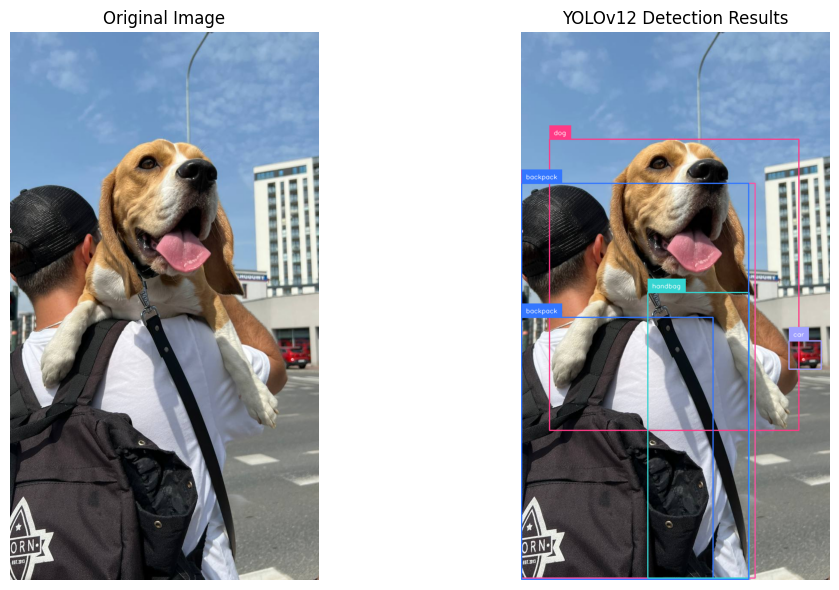

✅ YOLOv12 test successful! Detected 6 objects


In [18]:
# Download a test image
!wget -q https://media.roboflow.com/notebooks/examples/dog.jpeg -O test_image.jpg

# Test YOLOv12 inference
print("🧪 Testing YOLOv12 inference...")

try:
    # Load YOLOv12 model
    test_model = YOLO('yolov12s.pt')

    # Load and process image
    image_path = "test_image.jpg"
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Run inference
    results = test_model(image_path, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)

    # Visualize results
    box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator()

    annotated_image = image_rgb.copy()
    annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections)
    annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

    # Display
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(annotated_image)
    plt.title("YOLOv12 Detection Results")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    print(f"✅ YOLOv12 test successful! Detected {len(detections)} objects")

    # Clean up
    del test_model

except Exception as e:
    print(f"❌ YOLOv12 test failed: {e}")
    print("Please check your installation")

# 🚀 YOLOv12 Model Training Pipeline

<div style="background: linear-gradient(135deg, #ff6b6b 0%, #ee5a24 100%); padding: 20px; border-radius: 12px; color: white; margin: 15px 0;">
    <h2 style="margin: 0; color: white;">🎯 Training Configuration & Setup</h2>
    <p style="margin: 10px 0 0 0; opacity: 0.95;">Optimized parameters for Bangladesh street food detection with memory-efficient settings</p>
</div>

## ⚙️ Training Configuration

Configure YOLOv12 training parameters specifically optimized for:
- **🍛 Bangladesh street food detection**
- **💾 Memory-efficient training**
- **⚡ GPU acceleration**
- **📊 Performance monitoring**

### 🎛️ Key Training Parameters:
- **Model**: YOLOv12 Medium (balance of speed/accuracy)
- **Epochs**: 100 with early stopping
- **Batch Size**: 4 (memory optimized)
- **Image Size**: 416x416 (efficient processing)
- **Optimizer**: AdamW with cosine learning rate

---

In [19]:
YOLOV12_CONFIG = {
    # Model Configuration
    'model_size': 'yolov12m',  # Use medium version to reduce memory usage
    'model_weights': 'yolov12m.pt',  # Smaller pretrained weights

    # Memory-Optimized Training Parameters
    'epochs': 100,
    'batch_size': 4,    # Reduced from 16 to 4 to prevent OOM
    'imgsz': 416,       # Reduced from 640 to 416 to save memory
    'patience': 30,
    'save_period': 10,
    'workers': 2,       # Reduced from 8 to 2 to prevent worker crashes
    'device': 0 if torch.cuda.is_available() else 'cpu',

    # Project Settings
    'project': 'yolov12_bangladesh_street_food_optimized',
    'name': f'yolov12n_3classes_{"_".join(SELECTED_CLASSES)}_optimized',
    'exist_ok': True,

    # Optimization (Memory-friendly)
    'optimizer': 'AdamW',
    'lr0': 0.005,      # Slightly reduced learning rate
    'lrf': 0.001,
    'momentum': 0.937,
    'weight_decay': 0.0005,
    'warmup_epochs': 3,
    'warmup_momentum': 0.8,
    'warmup_bias_lr': 0.1,

    # Loss Configuration
    'box': 7.5,
    'cls': 0.5,
    'dfl': 1.5,
    'label_smoothing': 0.0,

    # Memory-Optimized Performance Settings
    'amp': True,        # Keep AMP for efficiency
    'half': False,      # Disabled for stability
    'cache': False,     # DISABLED to prevent memory issues
    'cos_lr': True,
    'close_mosaic': 15,

    # Validation
    'val': True,
    'plots': True,
    'save_json': True,
    'conf': 0.001,
    'iou': 0.6,
    'max_det': 300,

    # Reduced Augmentation (less memory intensive)
    'hsv_h': 0.01,     # Reduced
    'hsv_s': 0.5,      # Reduced
    'hsv_v': 0.3,      # Reduced
    'degrees': 0.0,
    'translate': 0.05, # Reduced
    'scale': 0.3,      # Reduced
    'shear': 0.0,
    'perspective': 0.0,
    'flipud': 0.0,
    'fliplr': 0.5,
    'mosaic': 0.8,     # Reduced probability
    'mixup': 0.0,
    'copy_paste': 0.0,
}

print(f"🔧 YOLOv12 Training Configuration:")
print(f"Model: {YOLOV12_CONFIG['model_size']}")
print(f"Epochs: {YOLOV12_CONFIG['epochs']}")
print(f"Batch Size: {YOLOV12_CONFIG['batch_size']}")
print(f"Image Size: {YOLOV12_CONFIG['imgsz']}")
print(f"Device: {YOLOV12_CONFIG['device']}")
print(f"Classes: {len(SELECTED_CLASSES)} ({', '.join(SELECTED_CLASSES)})")
print(f"Learning Rate: {YOLOV12_CONFIG['lr0']}")
print(f"Optimizer: {YOLOV12_CONFIG['optimizer']}")

🔧 YOLOv12 Training Configuration:
Model: yolov12m
Epochs: 100
Batch Size: 4
Image Size: 416
Device: 0
Classes: 3 (singara, peyaju, beguni)
Learning Rate: 0.005
Optimizer: AdamW


## Train YOLOv12 Model

Now we'll train the YOLOv12 model on our Bangladesh street food dataset.

In [20]:
def train_yolov12_bangladesh_food(dataset_path, config):
    """Train YOLOv12 on Bangladesh Street Food dataset"""

    print(f"🚀 Starting YOLOv12 Training")
    print(f"{'='*50}")
    print(f"Dataset: {dataset_path}")
    print(f"Model: {config['model_size']}")
    print(f"Classes: {SELECTED_CLASSES}")

    # Initialize model - Use pretrained weights for better results
    try:
        model = YOLO(config['model_weights'])
        print(f"✅ YOLOv12 model initialized with pretrained weights: {config['model_weights']}")
    except Exception as e:
        print(f"⚠️ Failed to load pretrained weights, trying YAML: {e}")
        try:
            model = YOLO(f"{config['model_size']}.yaml")
            print(f"✅ YOLOv12 model initialized from YAML")
        except Exception as e2:
            print(f"❌ Failed to initialize model: {e2}")
            return None, None

    # Training arguments (corrected parameter names)
    train_args = {
        'data': f"{dataset_path}/data.yaml",
        'epochs': config['epochs'],
        'batch': config['batch_size'],
        'imgsz': config['imgsz'],
        'patience': config['patience'],
        'save_period': config['save_period'],
        'workers': config['workers'],
        'device': config['device'],
        'project': config['project'],
        'name': config['name'],
        'exist_ok': config['exist_ok'],
        'optimizer': config['optimizer'],
        'lr0': config['lr0'],
        'lrf': config['lrf'],
        'momentum': config['momentum'],
        'weight_decay': config['weight_decay'],
        'warmup_epochs': config['warmup_epochs'],
        'box': config['box'],
        'cls': config['cls'],
        'dfl': config['dfl'],
        'amp': config['amp'],
        'cache': config['cache'],
        'cos_lr': config['cos_lr'],
        'val': config['val'],
        'plots': config['plots'],
        'conf': config['conf'],
        'iou': config['iou'],
        'hsv_h': config['hsv_h'],
        'hsv_s': config['hsv_s'],
        'hsv_v': config['hsv_v'],
        'degrees': config['degrees'],
        'translate': config['translate'],
        'scale': config['scale'],
        'fliplr': config['fliplr'],
        'mosaic': config['mosaic'],
    }

    # Add optional parameters only if they're not disabled
    if config.get('mixup', 0) > 0:
        train_args['mixup'] = config['mixup']
    if config.get('copy_paste', 0) > 0:
        train_args['copy_paste'] = config['copy_paste']
    if config.get('label_smoothing', 0) > 0:
        train_args['label_smoothing'] = config['label_smoothing']

    # Start training with timing
    start_time = time.time()
    print(f"\n⏱️ Training started at {time.strftime('%Y-%m-%d %H:%M:%S')}")

    try:
        results = model.train(**train_args)
        training_time = time.time() - start_time

        print(f"\n✅ Training completed successfully!")
        print(f"Training time: {training_time/3600:.2f} hours")
        print(f"Results saved to: {config['project']}/{config['name']}")

        return model, results

    except Exception as e:
        print(f"❌ Training failed: {e}")
        import traceback
        traceback.print_exc()
        return None, None

# GPU memory optimization
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.backends.cudnn.benchmark = True
    print("✅ GPU memory optimized")

# Start training
if dataset_path and os.path.exists(dataset_path):
    trained_model, training_results = train_yolov12_bangladesh_food(dataset_path, YOLOV12_CONFIG)

    if trained_model:
        best_model_path = f"{YOLOV12_CONFIG['project']}/{YOLOV12_CONFIG['name']}/weights/best.pt"
        print(f"\n💾 Best model saved: {best_model_path}")
    else:
        print("❌ Training failed")
else:
    print("❌ No dataset available for training")

✅ GPU memory optimized
🚀 Starting YOLOv12 Training
Dataset: /content/Bangladeshi-street-food-Dataset-3_3classes_balanced
Model: yolov12m
Classes: ['singara', 'peyaju', 'beguni']


100%|██████████| 38.0M/38.0M [00:00<00:00, 62.0MB/s]

✅ YOLOv12 model initialized with pretrained weights: yolov12m.pt

⏱️ Training started at 2025-06-30 17:56:24
New https://pypi.org/project/ultralytics/8.3.161 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)


engine/trainer: task=detect, mode=train, model=yolov12m.pt, data=/content/Bangladeshi-street-food-Dataset-3_3classes_balanced/data.yaml, epochs=100, time=None, patience=30, batch=4, imgsz=416, save=True, save_period=10, cache=False, device=0, workers=2, project=yolov12_bangladesh_street_food_optimized, name=yolov12n_3classes_singara_peyaju_beguni_optimized, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=0.001, iou=0.6, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_

100%|██████████| 755k/755k [00:00<00:00, 20.0MB/s]


...

    100/100      1.62G     0.5399     0.5751      1.008          2        416: 100%|██████████| 337/337 [00:57<00:00,  5.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 48/48 [00:05<00:00,  9.58it/s]

                   all        382        639      0.896      0.768      0.877      0.751



100 epochs completed in 1.853 hours.
Optimizer stripped from yolov12_bangladesh_street_food_optimized/yolov12n_3classes_singara_peyaju_beguni_optimized/weights/last.pt, 39.7MB
Optimizer stripped from yolov12_bangladesh_street_food_optimized/yolov12n_3classes_singara_peyaju_beguni_optimized/weights/best.pt, 39.7MB

Validating yolov12_bangladesh_street_food_optimized/yolov12n_3classes_singara_peyaju_beguni_optimized/weights/best.pt...
Ultralytics 8.3.63 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12m summary (fused): 402 layers, 19,578,841 parameters, 0 gradients, 59.5 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 48/48 [00:04<00:00, 11.80it/s]


                   all        382        639      0.915      0.758      0.877      0.753
               singara         74        128      0.895      0.695      0.811      0.726
                peyaju        202        329      0.927      0.772      0.912      0.786
                beguni        122        182      0.922      0.808      0.909      0.747
Speed: 0.1ms preprocess, 5.3ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to yolov12_bangladesh_street_food_optimized/yolov12n_3classes_singara_peyaju_beguni_optimized

✅ Training completed successfully!
Training time: 1.86 hours
Results saved to: yolov12_bangladesh_street_food_optimized/yolov12n_3classes_singara_peyaju_beguni_optimized

💾 Best model saved: yolov12_bangladesh_street_food_optimized/yolov12n_3classes_singara_peyaju_beguni_optimized/weights/best.pt


# 📊 Model Evaluation & Performance Analysis

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 20px; border-radius: 12px; color: white; margin: 15px 0;">
    <h2 style="margin: 0; color: white;">🔍 Training Results & Metrics</h2>
    <p style="margin: 10px 0 0 0; opacity: 0.95;">Comprehensive analysis of model performance, accuracy metrics, and training progression</p>
</div>

## 📈 Training Results Analysis

Analyze the training results and evaluate model performance across multiple metrics:
- **📊 Training/Validation Loss Curves**
- **🎯 mAP (Mean Average Precision) Scores**
- **🔄 Confusion Matrix Analysis**
- **⚡ Inference Speed Benchmarks**

---

📊 Training Results Directory: yolov12_bangladesh_street_food_optimized/yolov12n_3classes_singara_peyaju_beguni_optimized
args.yaml					    train_batch1.jpg
confusion_matrix_normalized.png			    train_batch2.jpg
confusion_matrix.png				    train_batch30330.jpg
events.out.tfevents.1751306191.b9ec5010c9ce.6549.0  train_batch30331.jpg
F1_curve.png					    train_batch30332.jpg
labels_correlogram.jpg				    val_batch0_labels.jpg
labels.jpg					    val_batch0_pred.jpg
P_curve.png					    val_batch1_labels.jpg
PR_curve.png					    val_batch1_pred.jpg
R_curve.png					    val_batch2_labels.jpg
results.csv					    val_batch2_pred.jpg
results.png					    weights
train_batch0.jpg


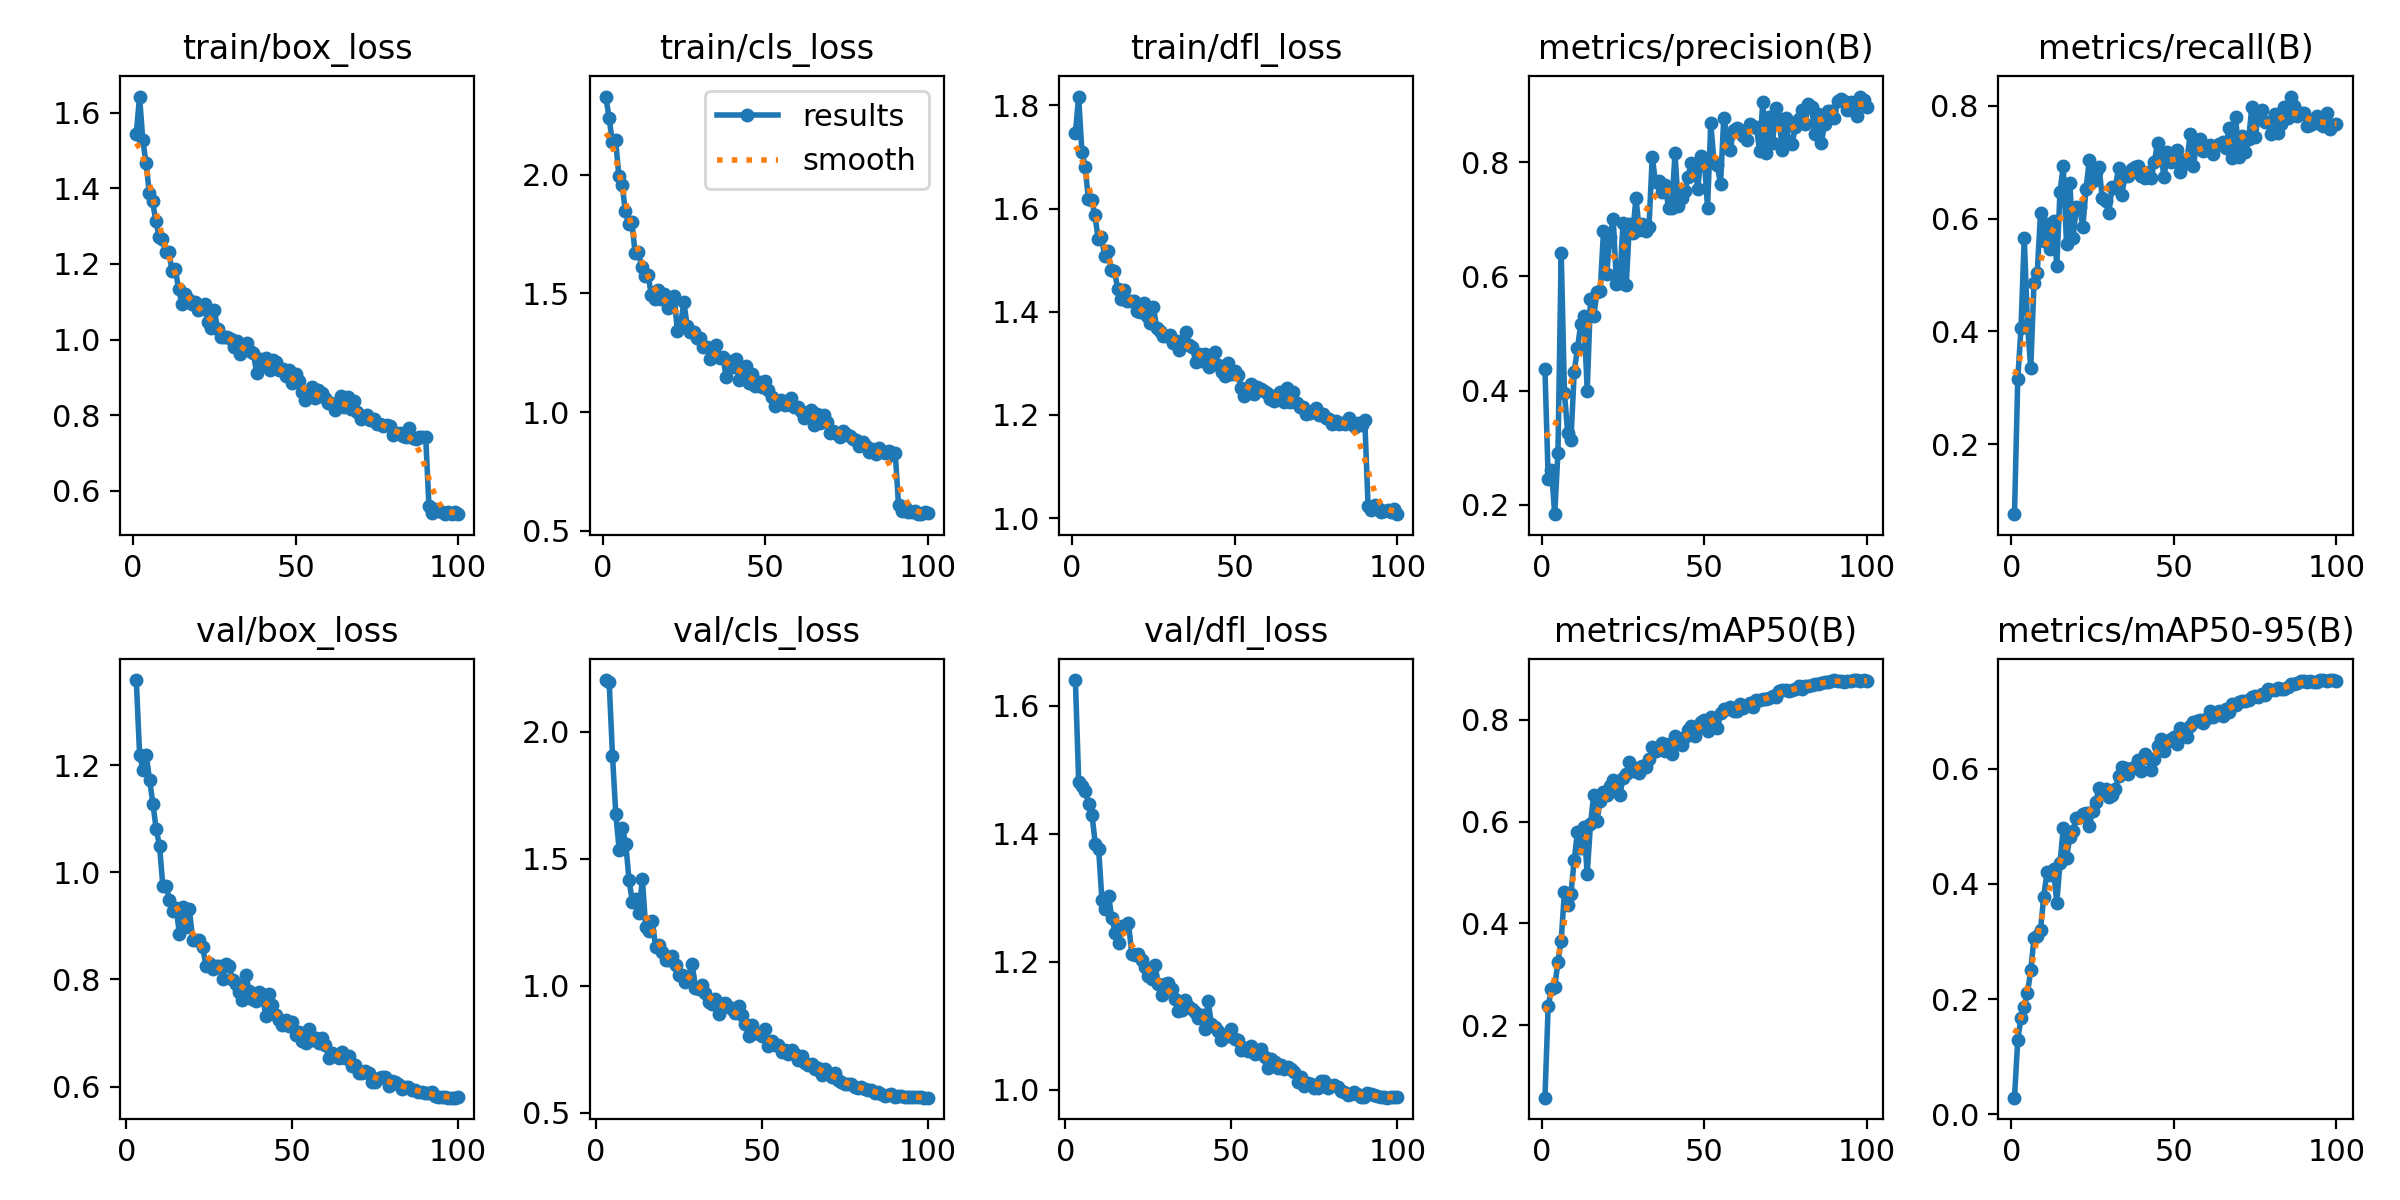

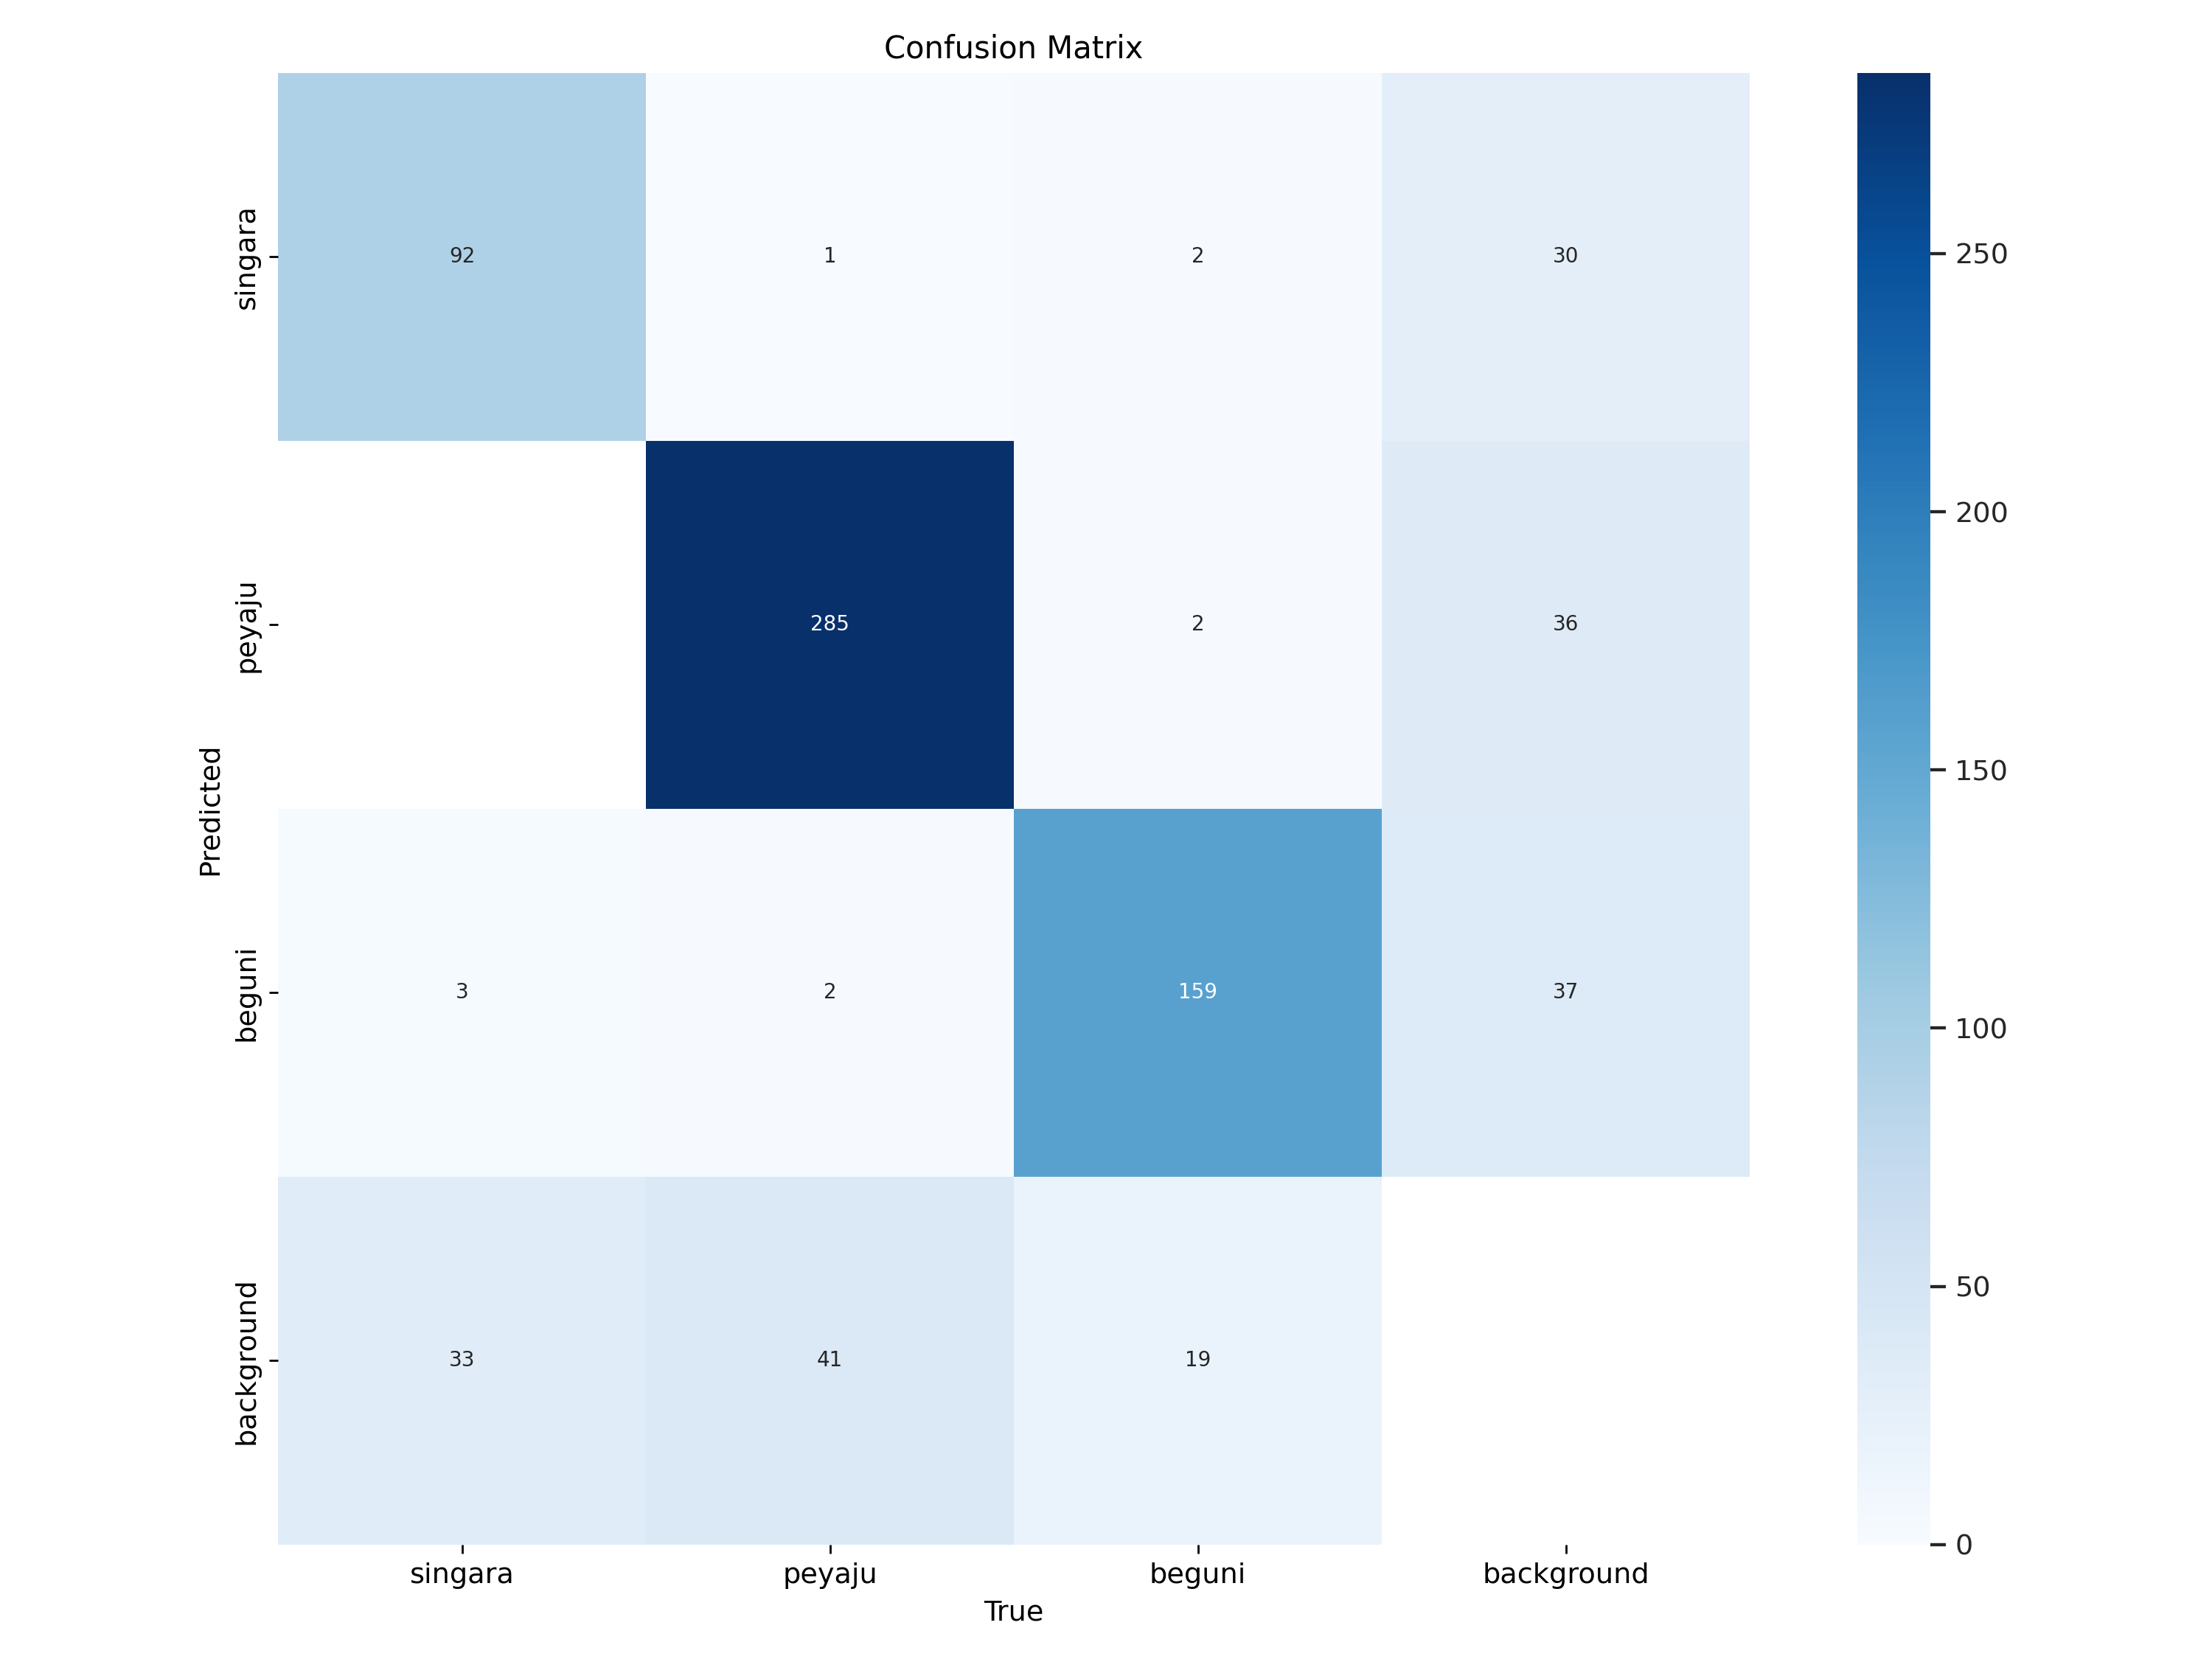

In [21]:
# Display training results
if 'best_model_path' in locals() and os.path.exists(best_model_path):
    results_dir = f"{YOLOV12_CONFIG['project']}/{YOLOV12_CONFIG['name']}"

    print(f"📊 Training Results Directory: {results_dir}")
    !ls {results_dir}

    # Display training curves
    results_plot = f"{results_dir}/results.png"
    if os.path.exists(results_plot):
        from IPython.display import Image, display
        display(Image(filename=results_plot, width=1000))

    # Display confusion matrix
    confusion_matrix = f"{results_dir}/confusion_matrix.png"
    if os.path.exists(confusion_matrix):
        display(Image(filename=confusion_matrix, width=800))
else:
    print("No trained model available for evaluation")

## 🔬 Comprehensive Model Evaluation

<div style="background: #e3f2fd; border: 2px solid #2196f3; border-radius: 10px; padding: 15px; margin: 12px 0;">
    <h4 style="margin: 0 0 8px 0; color: #1976d2;">🎯 Advanced Performance Metrics</h4>
    <p style="margin: 0; color: #1565c0;">
        Detailed evaluation using Supervision library for comprehensive performance analysis
        including per-class metrics and detection quality assessment.
    </p>
</div>

🔍 Comprehensive Model Evaluation
Test dataset loaded: 190 images
Classes: ['singara', 'peyaju', 'beguni']
Running inference on test set...
  Processed 0/190 images
  Processed 20/190 images
  Processed 40/190 images
  Processed 60/190 images
  Processed 80/190 images
  Processed 100/190 images
  Processed 120/190 images
  Processed 140/190 images
  Processed 160/190 images
  Processed 180/190 images

📈 YOLOv12 Bangladesh Street Food Detection Results:
mAP 50-95: 0.6661
mAP 50: 0.7529
mAP 75: 0.7206


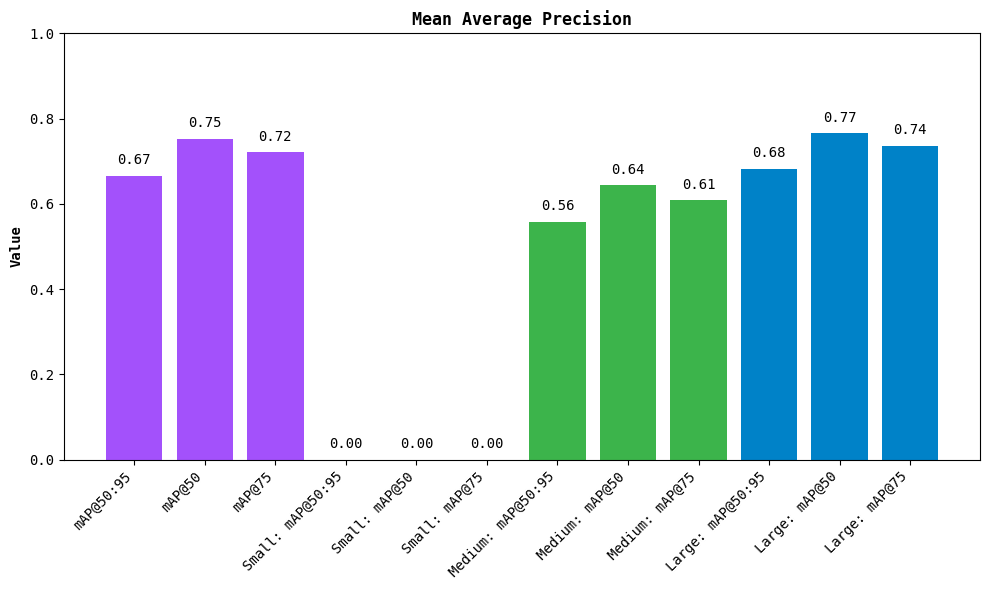

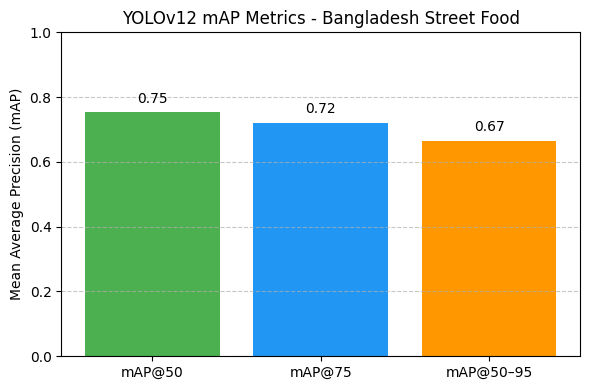

In [22]:
if 'best_model_path' in locals() and os.path.exists(best_model_path):
    print("🔍 Comprehensive Model Evaluation")

    # Load the trained model
    model = YOLO(best_model_path)

    # Load test dataset using supervision
    try:
        ds = sv.DetectionDataset.from_yolo(
            images_directory_path=f"{dataset_path}/test/images",
            annotations_directory_path=f"{dataset_path}/test/labels",
            data_yaml_path=f"{dataset_path}/data.yaml"
        )

        print(f"Test dataset loaded: {len(ds)} images")
        print(f"Classes: {ds.classes}")

        # Run inference on test set
        predictions = []
        targets = []

        print("Running inference on test set...")
        for i, (_, image, target) in enumerate(ds):
            if i % 20 == 0:
                print(f"  Processed {i}/{len(ds)} images")

            results = model(image, verbose=False)[0]
            detections = sv.Detections.from_ultralytics(results)

            predictions.append(detections)
            targets.append(target)

        # Calculate metrics
        from supervision.metrics import MeanAveragePrecision
        import matplotlib.pyplot as plt

        map_metric = MeanAveragePrecision().update(predictions, targets).compute()

        print(f"\n📈 YOLOv12 Bangladesh Street Food Detection Results:")
        print(f"mAP 50-95: {map_metric.map50_95:.4f}")
        print(f"mAP 50: {map_metric.map50:.4f}")
        print(f"mAP 75: {map_metric.map75:.4f}")

        # Plot results
        try:
            fig = map_metric.plot()
            map_scores = {
                "mAP@50": map_metric.map50,
                "mAP@75": map_metric.map75,
                "mAP@50–95": map_metric.map50_95
            }

            plt.figure(figsize=(6, 4))
            bars = plt.bar(map_scores.keys(), map_scores.values(), color=["#4CAF50", "#2196F3", "#FF9800"])
            plt.ylim(0, 1)
            plt.title("YOLOv12 mAP Metrics - Bangladesh Street Food")
            plt.ylabel("Mean Average Precision (mAP)")
            plt.grid(axis="y", linestyle="--", alpha=0.7)

            # Annotate bars
            for bar in bars:
                yval = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f"{yval:.2f}", ha='center', va='bottom', fontsize=10)

            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Could not display mAP plot: {e}")

    except Exception as e:
        print(f"❌ Evaluation failed: {e}")
else:
    print("No trained model available for evaluation")

# 🎯 Trained Model Inference Demo

<div style="background: linear-gradient(45deg, #ff6b6b, #ffa726); padding: 18px; border-radius: 12px; color: white; margin: 15px 0;">
    <h3 style="margin: 0; color: white;">🚀 Real-World Detection Testing</h3>
    <p style="margin: 8px 0 0 0; opacity: 0.95">Testing the trained YOLOv12 model on sample Bangladesh street food images</p>
</div>

## 🔍 Inference on Test Images

Put our trained model to work! Let's test it on sample images from our test dataset to see how well it can detect:
- 🔺 **Singara** detection accuracy
- 🧅 **Peyaju** recognition capability  
- 🍆 **Beguni** identification precision

### 📸 Detection Results Preview

---

🎯 YOLOv12 Inference Demo on Bangladesh Street Food
Running inference on 3 sample images...


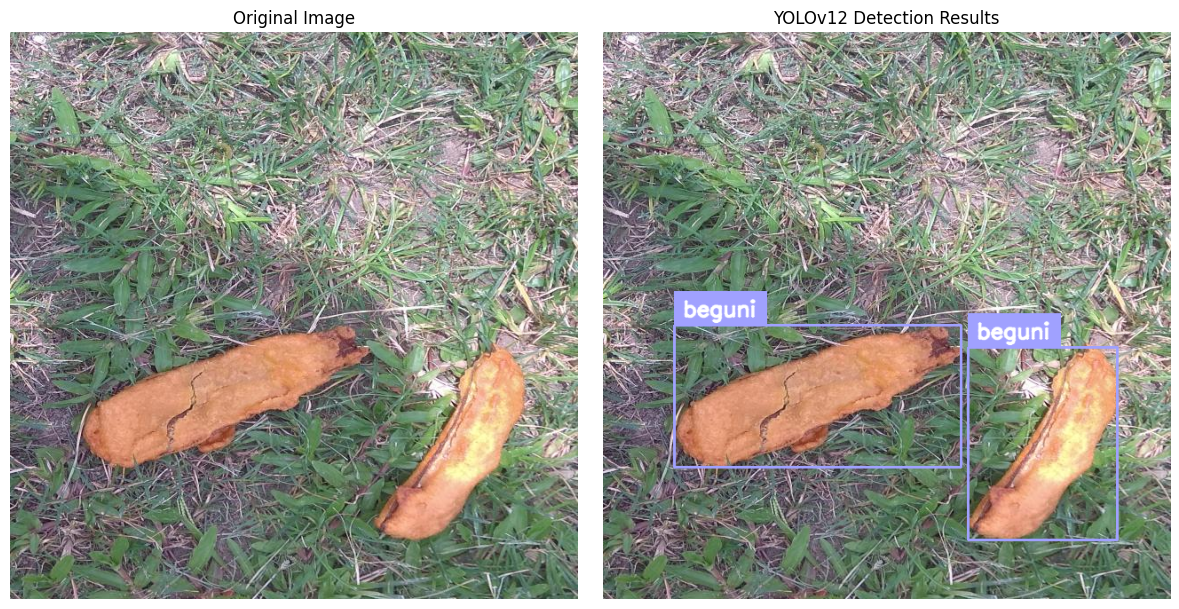


Detections in Image 1:
  1. beguni: 0.936
  2. beguni: 0.933
--------------------------------------------------


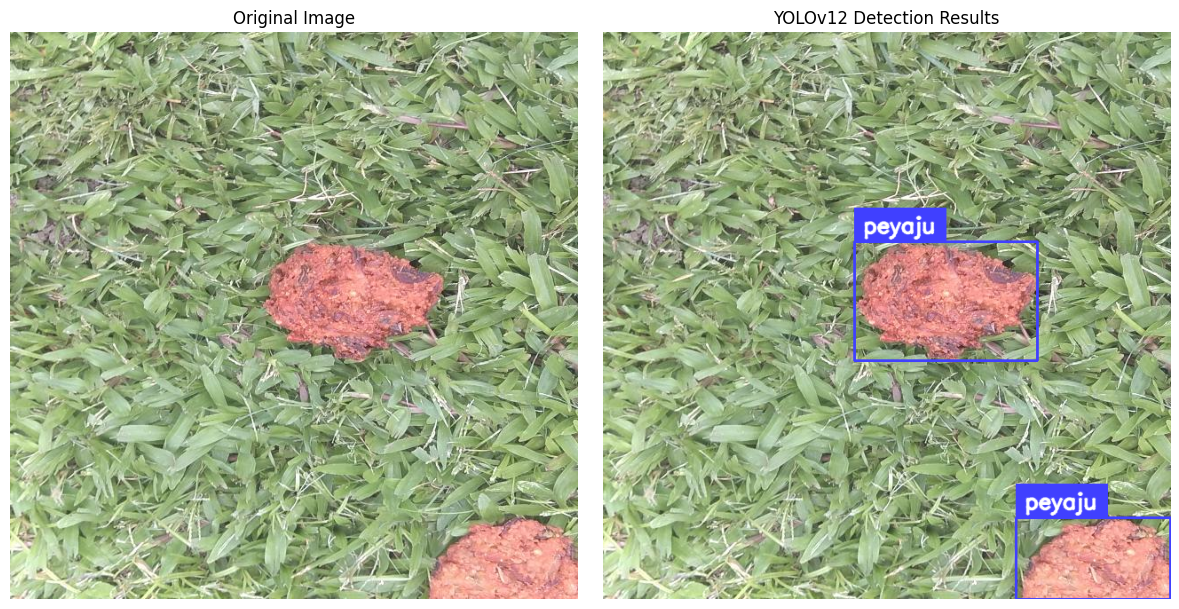


Detections in Image 2:
  1. peyaju: 0.920
  2. peyaju: 0.876
--------------------------------------------------


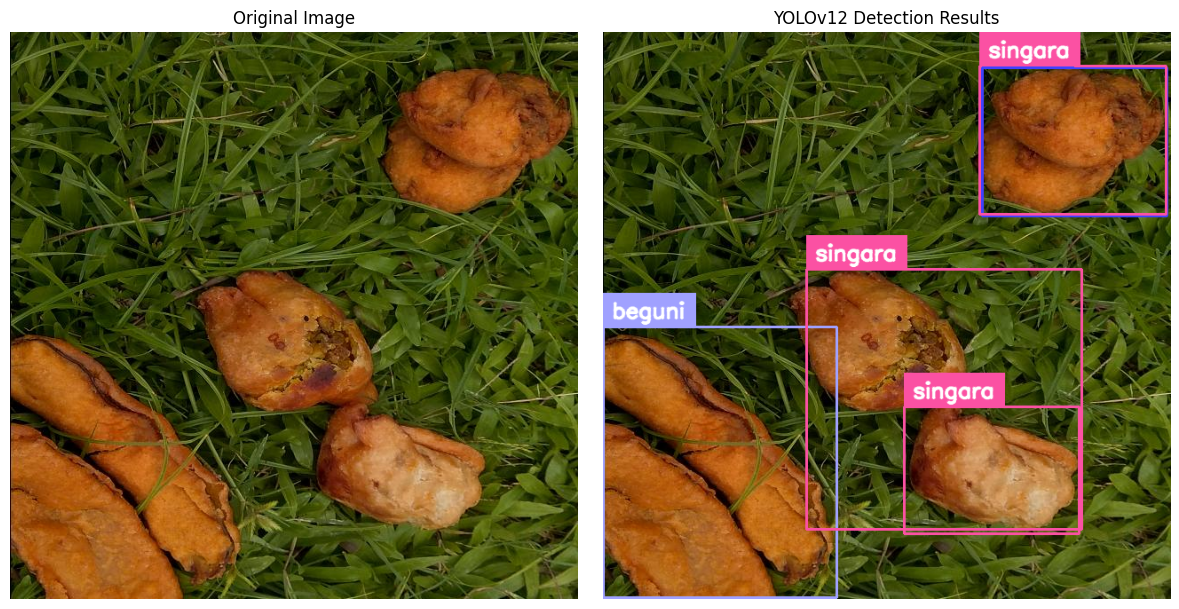


Detections in Image 3:
  1. beguni: 0.789
  2. singara: 0.574
  3. peyaju: 0.529
  4. singara: 0.426
  5. singara: 0.348
--------------------------------------------------


In [23]:
if 'best_model_path' in locals() and os.path.exists(best_model_path):
    print("🎯 YOLOv12 Inference Demo on Bangladesh Street Food")

    # Load trained model
    model = YOLO(best_model_path)

    # Load test dataset for visualization
    ds = sv.DetectionDataset.from_yolo(
        images_directory_path=f"{dataset_path}/test/images",
        annotations_directory_path=f"{dataset_path}/test/labels",
        data_yaml_path=f"{dataset_path}/data.yaml"
    )

    # Select random test images
    num_samples = min(3, len(ds))
    sample_indices = random.sample(range(len(ds)), num_samples)

    print(f"Running inference on {num_samples} sample images...")

    for i, idx in enumerate(sample_indices):
        image_path, image, target = ds[idx]

        # Convert image to RGB for display
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Run inference
        results = model(image_path, conf=0.25, iou=0.45, verbose=False)[0]
        detections = sv.Detections.from_ultralytics(results)

        # Apply NMS if needed
        if len(detections) > 0:
            detections = detections.with_nms(threshold=0.45)

        # Annotate image (using your requested format)
        box_annotator = sv.BoxAnnotator(thickness=2, color_lookup=sv.ColorLookup.CLASS)
        label_annotator = sv.LabelAnnotator(text_thickness=2, text_scale=0.8, color_lookup=sv.ColorLookup.CLASS)

        annotated_image = image_rgb.copy()
        annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections)
        annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

        # Display results (using your requested format)
        plt.figure(figsize=(12, 6))

        plt.subplot(1, 2, 1)
        plt.imshow(image_rgb)
        plt.title("Original Image")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(annotated_image)
        plt.title("YOLOv12 Detection Results")
        plt.axis('off')

        plt.tight_layout()
        plt.show()

        # Print detection details
        if len(detections) > 0:
            print(f"\nDetections in Image {i+1}:")
            for j, (class_id, conf) in enumerate(zip(detections.class_id, detections.confidence)):
                class_name = SELECTED_CLASSES[class_id] if class_id < len(SELECTED_CLASSES) else f"Class_{class_id}"
                print(f"  {j+1}. {class_name}: {conf:.3f}")
        else:
            print(f"\nImage {i+1}: No detections found")

        print("-" * 50)
else:
    print("❌ No trained model available for inference")

# 📦 Model Export & Deployment Preparation

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 20px; border-radius: 12px; color: white; margin: 15px 0;">
    <h2 style="margin: 0; color: white;">🚀 Production-Ready Model Formats</h2>
    <p style="margin: 10px 0 0 0; opacity: 0.95">Export trained YOLOv12 model in multiple formats for different deployment scenarios</p>
</div>

## 🔄 Export Formats

Prepare your trained model for various deployment environments:

| Format | Use Case | Performance | Compatibility |
|--------|----------|-------------|---------------|
| **ONNX** | Cross-platform deployment | High | Universal |
| **TensorRT** | NVIDIA GPU optimization | Highest | NVIDIA only |
| **CoreML** | iOS/macOS deployment | High | Apple devices |
| **TensorFlow Lite** | Mobile/edge deployment | Medium | Mobile devices |

---

In [24]:
if 'best_model_path' in locals() and os.path.exists(best_model_path):
    print("📦 Exporting YOLOv12 Model for Deployment")

    model = YOLO(best_model_path)

    # Export to ONNX (recommended for deployment)
    try:
        print("Exporting to ONNX format...")
        onnx_path = model.export(
            format='onnx',
            imgsz=640,
            dynamic=False,  # Static shapes for better compatibility
            simplify=True,
            opset=12,       # Standard opset for compatibility
            half=False      # Keep FP32 for better compatibility
        )
        print(f"✅ ONNX export successful: {onnx_path}")
    except Exception as e:
        print(f"❌ ONNX export failed: {e}")

    # Export to TensorRT (for NVIDIA GPUs) - Optional
    if torch.cuda.is_available():
        try:
            print("Exporting to TensorRT format...")
            trt_path = model.export(
                format='engine',
                imgsz=640,
                half=True,
                dynamic=False,
                workspace=4  # 4GB workspace
            )
            print(f"✅ TensorRT export successful: {trt_path}")
        except Exception as e:
            print(f"⚠️ TensorRT export failed (this is normal if TensorRT is not installed): {e}")

    print("\n🚀 Model ready for deployment!")
else:
    print("❌ No trained model available for export")

📦 Exporting YOLOv12 Model for Deployment
Exporting to ONNX format...
Ultralytics 8.3.63 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.00GHz)
YOLOv12m summary (fused): 402 layers, 19,578,841 parameters, 0 gradients, 59.5 GFLOPs

PyTorch: starting from 'yolov12_bangladesh_street_food_optimized/yolov12n_3classes_singara_peyaju_beguni_optimized/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (37.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0', 'onnxslim', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 305.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 373.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 283.2/283.2 MB 189.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 197.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

# ⚡ Performance Benchmarking & Speed Analysis

<div style="background: linear-gradient(45deg, #ff6b6b, #ffa726); padding: 18px; border-radius: 12px; color: white; margin: 15px 0;">
    <h3 style="margin: 0; color: white;">📊 Model Performance Metrics</h3>
    <p style="margin: 8px 0 0 0; opacity: 0.95">Comprehensive speed and efficiency analysis of the trained YOLOv12 model</p>
</div>

## 🏃‍♂️ Speed Benchmarking

Measure the real-world performance of our trained model:
- **⏱️ Inference Time** per image
- **🖼️ Frames Per Second (FPS)** capability
- **💾 Memory Usage** during inference
- **🎯 Detection Accuracy** vs speed trade-offs

### 📈 Benchmark Metrics

---

In [25]:
if 'best_model_path' in locals() and os.path.exists(best_model_path):
    print("⚡ YOLOv12 Performance Benchmark")

    model = YOLO(best_model_path)
    test_images_path = f"{dataset_path}/test/images"

    if os.path.exists(test_images_path):
        test_images = [f for f in os.listdir(test_images_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

        # Select subset for benchmarking
        benchmark_images = random.sample(test_images, min(50, len(test_images)))

        print(f"Benchmarking on {len(benchmark_images)} images...")

        # Warm up
        warmup_img = f"{test_images_path}/{benchmark_images[0]}"
        for _ in range(5):
            _ = model(warmup_img, verbose=False)

        # Benchmark
        inference_times = []
        total_detections = 0

        start_time = time.time()

        for i, img_name in enumerate(benchmark_images):
            img_path = f"{test_images_path}/{img_name}"

            # Measure inference time
            inf_start = time.time()
            results = model(img_path, conf=0.25, iou=0.7, verbose=False)[0]
            inf_time = time.time() - inf_start

            inference_times.append(inf_time)
            total_detections += len(results.boxes) if results.boxes is not None else 0

            if (i + 1) % 10 == 0:
                print(f"  Processed {i + 1}/{len(benchmark_images)} images")

        total_time = time.time() - start_time

        # Calculate statistics
        avg_inference_time = np.mean(inference_times)
        std_inference_time = np.std(inference_times)
        avg_fps = 1.0 / avg_inference_time
        avg_detections = total_detections / len(benchmark_images)

        print(f"\n📊 BENCHMARK RESULTS:")
        print(f"Images processed: {len(benchmark_images)}")
        print(f"Total time: {total_time:.2f}s")
        print(f"Average inference time: {avg_inference_time*1000:.2f} ± {std_inference_time*1000:.2f} ms")
        print(f"Average FPS: {avg_fps:.2f}")
        print(f"Min inference time: {min(inference_times)*1000:.2f} ms")
        print(f"Max inference time: {max(inference_times)*1000:.2f} ms")
        print(f"Total detections: {total_detections}")
        print(f"Average detections per image: {avg_detections:.2f}")

        if torch.cuda.is_available():
            gpu_memory = torch.cuda.max_memory_allocated() / 1024**3
            print(f"Peak GPU memory: {gpu_memory:.2f} GB")

    else:
        print("No test images found for benchmarking")
else:
    print("❌ No trained model available for benchmarking")

⚡ YOLOv12 Performance Benchmark
Benchmarking on 50 images...
  Processed 10/50 images
  Processed 20/50 images
  Processed 30/50 images
  Processed 40/50 images
  Processed 50/50 images

📊 BENCHMARK RESULTS:
Images processed: 50
Total time: 3.16s
Average inference time: 63.25 ± 24.84 ms
Average FPS: 15.81
Min inference time: 34.99 ms
Max inference time: 137.40 ms
Total detections: 98
Average detections per image: 1.96
Peak GPU memory: 13.17 GB


## Training Summary and Next Steps

Congratulations! You've successfully trained a YOLOv12 model for Bangladesh street food detection.

In [26]:
print("🎉 YOLOv12 Bangladesh Street Food Detection - Training Complete!")
print("=" * 70)

if 'best_model_path' in locals() and os.path.exists(best_model_path):
    print(f"\n📋 PROJECT SUMMARY:")
    print(f"Model Architecture: YOLOv12 ({YOLOV12_CONFIG['model_size']})")
    print(f"Dataset Classes: {SELECTED_CLASSES}")
    print(f"Training Epochs: {YOLOV12_CONFIG['epochs']}")
    print(f"Batch Size: {YOLOV12_CONFIG['batch_size']}")
    print(f"Image Size: {YOLOV12_CONFIG['imgsz']}")

    print(f"\n💾 MODEL OUTPUTS:")
    print(f"Best Model: {best_model_path}")
    print(f"Results Directory: {YOLOV12_CONFIG['project']}/{YOLOV12_CONFIG['name']}")

    print(f"\n🚀 NEXT STEPS:")
    print(f"1. Test model on new Bangladesh street food images")
    print(f"2. Deploy using exported ONNX format")
    print(f"3. Create mobile or web application")
    print(f"4. Consider expanding to more street food classes")
    print(f"5. Fine-tune on additional regional variations")

    print(f"\n🎯 Your YOLOv12 model is ready to detect:")
    for i, food in enumerate(SELECTED_CLASSES, 1):
        print(f"   {i}. {food}")

else:
    print("\n❌ Training was not completed successfully.")
    print("Please check the error messages above and retry.")

print(f"\n{'='*70}")
print("🍛 Happy Bangladesh Street Food Detection with YOLOv12! 🍛")
print(f"{'='*70}")

🎉 YOLOv12 Bangladesh Street Food Detection - Training Complete!

📋 PROJECT SUMMARY:
Model Architecture: YOLOv12 (yolov12m)
Dataset Classes: ['singara', 'peyaju', 'beguni']
Training Epochs: 100
Batch Size: 4
Image Size: 416

💾 MODEL OUTPUTS:
Best Model: yolov12_bangladesh_street_food_optimized/yolov12n_3classes_singara_peyaju_beguni_optimized/weights/best.pt
Results Directory: yolov12_bangladesh_street_food_optimized/yolov12n_3classes_singara_peyaju_beguni_optimized

🚀 NEXT STEPS:
1. Test model on new Bangladesh street food images
2. Deploy using exported ONNX format
3. Create mobile or web application
4. Consider expanding to more street food classes
5. Fine-tune on additional regional variations

🎯 Your YOLOv12 model is ready to detect:
   1. singara
   2. peyaju
   3. beguni

🍛 Happy Bangladesh Street Food Detection with YOLOv12! 🍛
